# Cuaderno para TFM

### Carga de datos y preparación

In [1]:
# descarga de datos, cálculo de indicadores, partición temporal y escalado
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.preprocessing import StandardScaler

UMBRAL_COMPRA = 0
GAP_DIAS      = 5

print("Descargando datos...")
df  = yf.download('^GSPC', start='2005-01-01', end='2025-12-31', auto_adjust=False)
vix = yf.download('^VIX',  start='2005-01-01', end='2025-12-31', auto_adjust=False)
tnx = yf.download('^TNX',  start='2005-01-01', end='2025-12-31', auto_adjust=False)

for d in (df, vix, tnx):
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.droplevel(1)

close_s  = df['Close'].squeeze()
high_s   = df['High'].squeeze()
low_s    = df['Low'].squeeze()
vix_s    = vix['Close'].reindex(df.index).ffill()
tnx_s    = tnx['Close'].reindex(df.index).ffill()
volume_s = df['Volume'].squeeze()

print("Calculando indicadores técnicos y exógenos...")

df['SMA_10_raw']  = ta.trend.SMAIndicator(close=close_s, window=10).sma_indicator()
df['SMA_10_NORM'] = df['Close'] / df['SMA_10_raw']

df['EMA_12_raw']  = ta.trend.EMAIndicator(close=close_s, window=12).ema_indicator()
df['EMA_12_NORM'] = df['Close'] / df['EMA_12_raw']

macd_calc      = ta.trend.MACD(close=close_s, window_fast=12, window_slow=26, window_sign=9)
df['MACD_raw'] = macd_calc.macd()
df['SIG_raw']  = macd_calc.macd_signal()
denom          = 0.5 * (df['MACD_raw'].abs() + df['SIG_raw'].abs())
df['rMACD']    = (df['MACD_raw'] - df['SIG_raw']) / denom.replace(0, np.nan)

df['RSI_7'] = ta.momentum.RSIIndicator(close=close_s, window=7).rsi() / 100

bb_calc      = ta.volatility.BollingerBands(close=close_s, window=20, window_dev=2)
df['BB_PCT'] = (df['Close'] - bb_calc.bollinger_lband()) / \
               (bb_calc.bollinger_hband() - bb_calc.bollinger_lband())
df['BB_PCT'] = df['BB_PCT'].clip(-0.5, 1.5)

df['ROC_5']  = close_s.pct_change(periods=5)
df['ROC_20'] = close_s.pct_change(periods=20)

df['STOCH'] = ta.momentum.StochasticOscillator(
    high=high_s, low=low_s, close=close_s, window=14, smooth_window=3).stoch() / 100

df['VIX_Z']     = (vix_s - vix_s.rolling(50).mean()) / vix_s.rolling(50).std()
df['TNX_CHG20'] = tnx_s.diff(20)

df['MFI_14'] = ta.volume.MFIIndicator(
    high=high_s, low=low_s, close=close_s, volume=volume_s, window=14
).money_flow_index() / 100

df['VOL_REL'] = volume_s / volume_s.rolling(20).mean()

df['ATR_PCT'] = ta.volatility.AverageTrueRange(
    high=high_s, low=low_s, close=close_s, window=14
).average_true_range() / close_s

df['BB_WIDTH'] = (bb_calc.bollinger_hband() - bb_calc.bollinger_lband()) / bb_calc.bollinger_mavg()

df['ADX_14'] = ta.trend.ADXIndicator(
    high=high_s, low=low_s, close=close_s, window=14
).adx() / 100

df['OPEN']  = df['Open']
df['HIGH']  = df['High']
df['LOW']   = df['Low']
df['CLOSE'] = df['Close']

df['Close_Future_5d'] = df['Close'].shift(-5)
df['Return_5d']       = (df['Close_Future_5d'] - df['Close']) / df['Close']
df['Target']          = (df['Return_5d'] >= UMBRAL_COMPRA).astype(int)

FEATURES = [
    'OPEN', 'HIGH', 'LOW', 'CLOSE',
    'SMA_10_NORM',
    'EMA_12_NORM',
    'rMACD',
    'RSI_7',
    'BB_PCT',
    'ROC_5',
    'ROC_20',
    'STOCH',
    'VIX_Z',
    'TNX_CHG20',
    'MFI_14',
    'VOL_REL',
    'ATR_PCT',
    'BB_WIDTH',
    'ADX_14',
]

dataset = pd.concat([df[FEATURES], df['Target']], axis=1).dropna()

n_total = len(dataset)
n_train = int(n_total * 0.8)

train = dataset.iloc[:n_train - GAP_DIAS]
test  = dataset.iloc[n_train:]

EFECTIVAS = [
    'SMA_10_NORM',
    'rMACD',
    'RSI_7',
    'ROC_5',
    'ROC_20',
    'VIX_Z',
    'TNX_CHG20',
    'MFI_14',
    'VOL_REL',
    'ATR_PCT',
    'BB_WIDTH',
    'ADX_14',
]

X_train_raw = train[EFECTIVAS].values
X_test_raw  = test[EFECTIVAS].values
y_train     = train['Target'].values
y_test      = test['Target'].values

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_raw)
X_test_s  = scaler.transform(X_test_raw)

print(f"\nVerificación del escalado:")
print(f"  Media X_train: {X_train_s.mean(axis=0).round(4).mean():.4f} (global)")
print(f"  Std X_train:   {X_train_s.std(axis=0).round(4).mean():.4f} (global)")

df_train_scaled           = pd.DataFrame(X_train_s, columns=EFECTIVAS, index=train.index)
df_train_scaled['Target'] = y_train

df_test_scaled            = pd.DataFrame(X_test_s, columns=EFECTIVAS, index=test.index)
df_test_scaled['Target']  = y_test

df_train_scaled.to_csv('SP500_Train_Scaled.csv')
df_test_scaled.to_csv('SP500_Test_Scaled.csv')
train.to_csv('SP500_Train_Raw.csv')
test.to_csv('SP500_Test_Raw.csv')

print(f"\nTrain: {train.index[0].date()} → {train.index[-1].date()} ({len(X_train_s)} muestras)")
print(f"Test:  {test.index[0].date()}  → {test.index[-1].date()}  ({len(X_test_s)} muestras)")
print(f"Clase 1 train: {y_train.mean()*100:.1f}%")
print(f"Clase 1 test:  {y_test.mean()*100:.1f}%")
print(f"\nFeatures efectivas ({len(EFECTIVAS)}): {', '.join(EFECTIVAS)}")
print(f"  · Técnicas:    SMA, MACD, RSI, ROC(5), ROC(20)")
print(f"  · Exógenas:    VIX_Z, TNX_CHG20")
print(f"  · Ortogonales: MFI_14, VOL_REL, ATR_PCT, BB_WIDTH, ADX_14")
print(f"  · Podadas (|r|>0.9): EMA_12_NORM, STOCH, BB_PCT")
print(f"\nVariables disponibles: X_train_s, X_test_s, y_train, y_test, scaler")
print(f"UMBRAL_COMPRA: {UMBRAL_COMPRA} | GAP_DIAS: {GAP_DIAS}")

Descargando datos...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Calculando indicadores técnicos y exógenos...

Verificación del escalado:
  Media X_train: 0.0000 (global)
  Std X_train:   1.0000 (global)

Train: 2005-03-15 → 2021-10-20 (4181 muestras)
Test:  2021-10-28  → 2025-12-30  (1047 muestras)
Clase 1 train: 59.4%
Clase 1 test:  58.5%

Features efectivas (12): SMA_10_NORM, rMACD, RSI_7, ROC_5, ROC_20, VIX_Z, TNX_CHG20, MFI_14, VOL_REL, ATR_PCT, BB_WIDTH, ADX_14
  · Técnicas:    SMA, MACD, RSI, ROC(5), ROC(20)
  · Exógenas:    VIX_Z, TNX_CHG20
  · Ortogonales: MFI_14, VOL_REL, ATR_PCT, BB_WIDTH, ADX_14
  · Podadas (|r|>0.9): EMA_12_NORM, STOCH, BB_PCT

Variables disponibles: X_train_s, X_test_s, y_train, y_test, scaler
UMBRAL_COMPRA: 0 | GAP_DIAS: 5


### EDA: matriz de correlación

EDA-1 — Matriz de correlación entre features técnicas/exógenas (train)
  Mostrando 15 features (incluidas las podadas por colinealidad)
Usando matplotlib para el heatmap


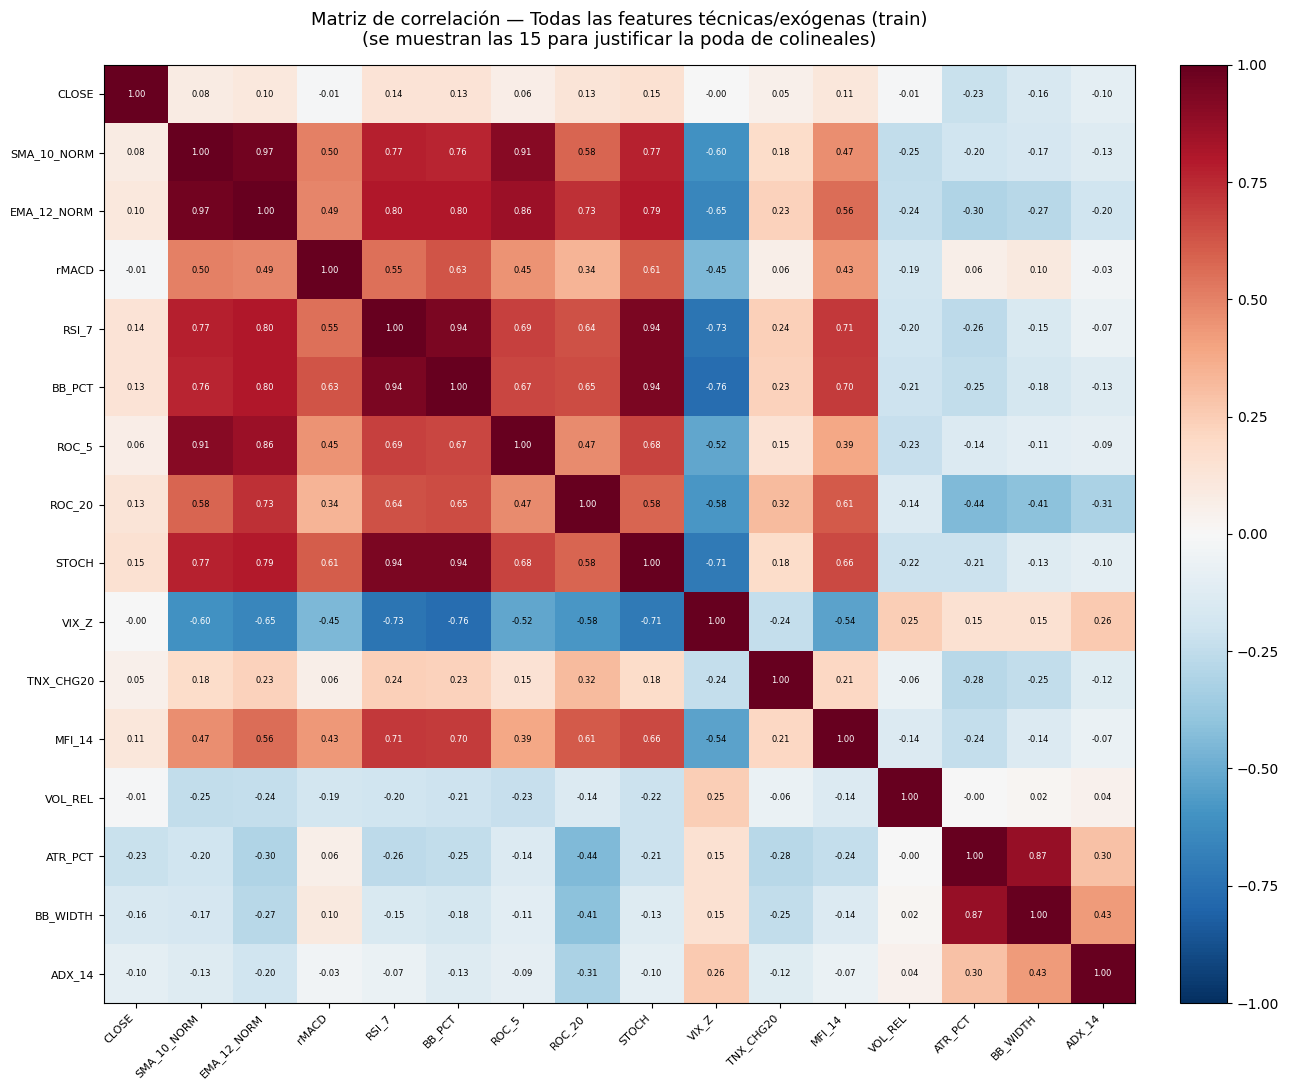


Pares con |r| > 0.9 (eliminados de EFECTIVAS: EMA_12_NORM, STOCH, BB_PCT):
  EMA_12_NORM — rMACD: 0.968
  BB_PCT — ROC_5: 0.944
  ROC_5 — VIX_Z: 0.943
  BB_PCT — VIX_Z: 0.938
  EMA_12_NORM — ROC_20: 0.911


In [2]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
    _seaborn = True
except ImportError:
    _seaborn = False

TECNICAS_ALL = [f for f in FEATURES if f not in ('OPEN', 'HIGH', 'LOW', 'CLOSE')]

print("EDA-1 — Matriz de correlación entre features técnicas/exógenas (train)")
print(f"  Mostrando {len(TECNICAS_ALL)} features (incluidas las podadas por colinealidad)")
print(f"Usando {'seaborn' if _seaborn else 'matplotlib'} para el heatmap")

COLS_CORR = ['CLOSE'] + TECNICAS_ALL
corr_matrix = train[COLS_CORR].corr()

fig, ax = plt.subplots(figsize=(13, 11))

if _seaborn:
    sns.heatmap(
        corr_matrix,
        annot=True, fmt=".2f", cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, linewidths=0.5, ax=ax,
        annot_kws={"size": 7}
    )
else:
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ticks = range(len(COLS_CORR))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(COLS_CORR, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(COLS_CORR, fontsize=8)
    for i in range(len(COLS_CORR)):
        for j in range(len(COLS_CORR)):
            ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                    ha='center', va='center', fontsize=6,
                    color='white' if abs(corr_matrix.iloc[i, j]) > 0.6 else 'black')

ax.set_title("Matriz de correlación — Todas las features técnicas/exógenas (train)\n"
             "(se muestran las 15 para justificar la poda de colineales)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

high_corr = [
    (TECNICAS_ALL[i], TECNICAS_ALL[j], corr_matrix.iloc[i, j])
    for i in range(len(TECNICAS_ALL))
    for j in range(i+1, len(TECNICAS_ALL))
    if abs(corr_matrix.iloc[i, j]) > 0.9
]
if high_corr:
    print("\nPares con |r| > 0.9 (eliminados de EFECTIVAS: EMA_12_NORM, STOCH, BB_PCT):")
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {a} — {b}: {r:.3f}")
else:
    print("\nNo hay pares con |r| > 0.9.")

### EDA: correlación con el objetivo

EDA-2 — Poder discriminante lineal individual (correlación con Target)


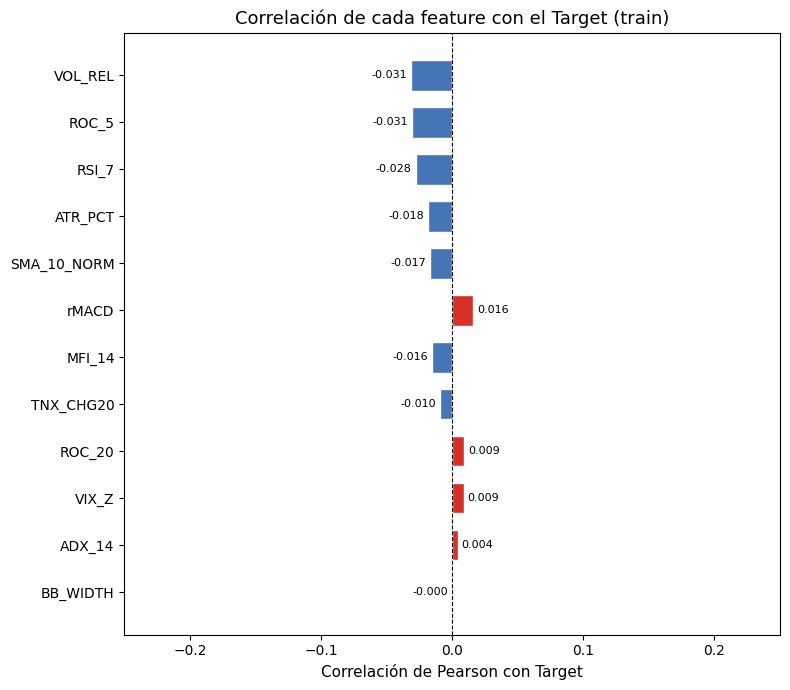

In [3]:
import matplotlib.pyplot as plt
import numpy as np

print("EDA-2 — Poder discriminante lineal individual (correlación con Target)")

corr_target = train[EFECTIVAS + ['Target']].corr()['Target'].drop('Target')
corr_sorted = corr_target.reindex(corr_target.abs().sort_values(ascending=True).index)

colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_sorted.values]

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Correlación de Pearson con Target", fontsize=11)
ax.set_title("Correlación de cada feature con el Target (train)", fontsize=13)
ax.set_xlim(-0.25, 0.25)

for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

### EDA: distribuciones por clase

EDA-3 — Distribuciones por clase (top-6 features con mayor |corr| con Target)


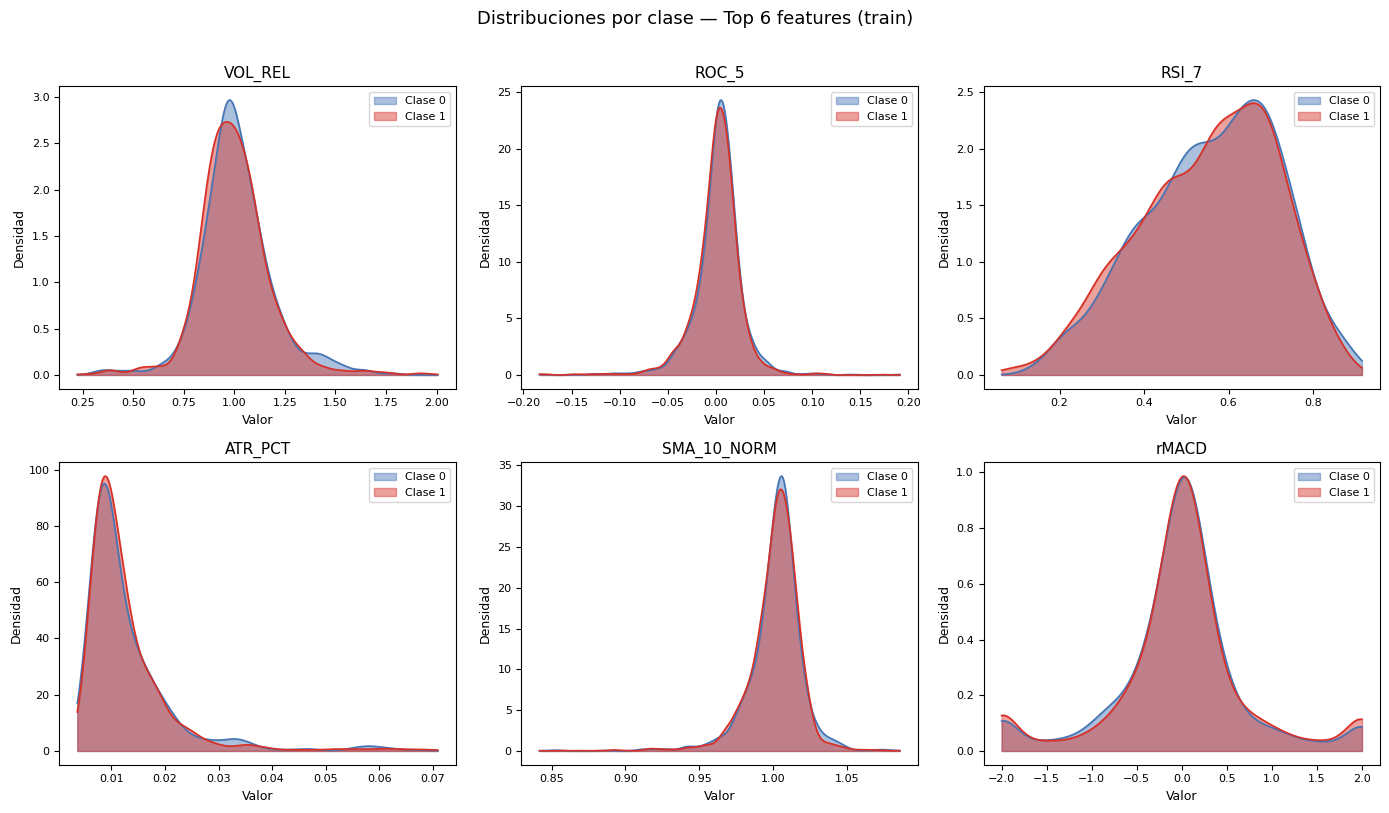

In [4]:
import matplotlib.pyplot as plt
import numpy as np

try:
    from scipy.stats import gaussian_kde
    _scipy = True
except ImportError:
    _scipy = False

print("EDA-3 — Distribuciones por clase (top-6 features con mayor |corr| con Target)")

corr_target = train[EFECTIVAS + ['Target']].corr()['Target'].drop('Target')
top6 = corr_target.abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

c0_data = train[train['Target'] == 0]
c1_data = train[train['Target'] == 1]

for ax, feat in zip(axes, top6):
    v0 = c0_data[feat].dropna().values
    v1 = c1_data[feat].dropna().values

    if _scipy and len(v0) > 10 and len(v1) > 10:
        lo = min(v0.min(), v1.min())
        hi = max(v0.max(), v1.max())
        xs = np.linspace(lo, hi, 300)
        ax.fill_between(xs, gaussian_kde(v0)(xs), alpha=0.45, color='#4575b4', label='Clase 0')
        ax.fill_between(xs, gaussian_kde(v1)(xs), alpha=0.45, color='#d73027', label='Clase 1')
        ax.plot(xs, gaussian_kde(v0)(xs), color='#4575b4', linewidth=1.2)
        ax.plot(xs, gaussian_kde(v1)(xs), color='#d73027', linewidth=1.2)
    else:
        bins = 40
        ax.hist(v0, bins=bins, density=True, alpha=0.5, color='#4575b4', label='Clase 0')
        ax.hist(v1, bins=bins, density=True, alpha=0.5, color='#d73027', label='Clase 1')

    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("Valor", fontsize=9)
    ax.set_ylabel("Densidad", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

fig.suptitle("Distribuciones por clase — Top 6 features (train)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### EDA: balance de clases

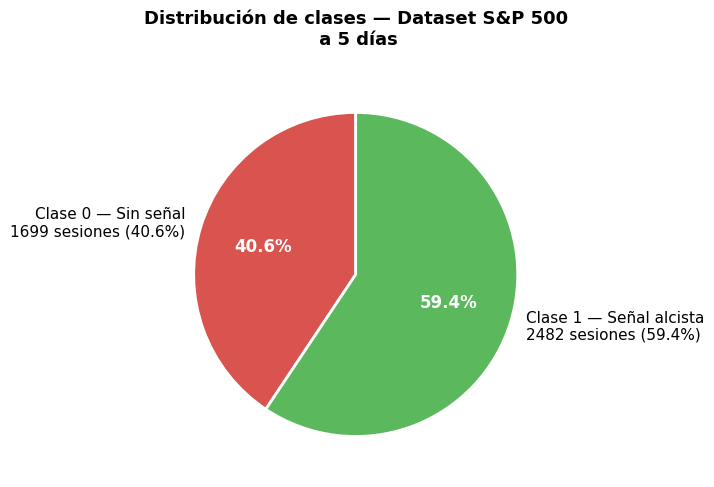

Gráfico guardado como balance_clases.png


In [5]:
import matplotlib.pyplot as plt

clase_0 = (y_train == 0).sum()
clase_1 = (y_train == 1).sum()
total   = len(y_train)

etiquetas = [
    f'Clase 0 — Sin señal\n{clase_0} sesiones ({round((clase_0/total)*100, 1)}%)',
    f'Clase 1 — Señal alcista\n{clase_1} sesiones ({round((clase_1/total)*100, 1)}%)'
]

colores = ['#d9534f', '#5cb85c']

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    [clase_0, clase_1],
    labels=etiquetas,
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title('Distribución de clases — Dataset S&P 500\n a 5 días',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"Gráfico guardado como balance_clases.png")

### Registro de modelos

In [6]:
import os
import csv
from datetime import datetime

LOG_FILE = "model_log.csv"

LOG_COLUMNS = [
    "timestamp",
    "modelo",
    "fase",
    "f1_score",
    "precision",
    "recall",
    "auc_roc",
    "rentabilidad_modelo",
    "rentabilidad_bh",
    "params",
    "notas",
]

def _init_log():
    if not os.path.exists(LOG_FILE):
        with open(LOG_FILE, "w", newline="", encoding="utf-8") as fh:
            writer = csv.DictWriter(fh, fieldnames=LOG_COLUMNS)
            writer.writeheader()

def log_resultado(modelo: str,
                  fase: str,
                  f1_score: float,
                  recall: float,
                  auc_roc: float,
                  precision: float = None,
                  rentabilidad_modelo: float = None,
                  rentabilidad_bh: float = None,
                  params: dict = None,
                  notas: str = ""):
    _init_log()
    row = {
        "timestamp"          : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "modelo"             : modelo,
        "fase"               : fase,
        "f1_score"           : round(f1_score, 4),
        "precision"          : round(precision, 4) if precision is not None else "",
        "recall"             : round(recall, 4),
        "auc_roc"            : round(auc_roc, 4),
        "rentabilidad_modelo": round(rentabilidad_modelo, 2) if rentabilidad_modelo is not None else "",
        "rentabilidad_bh"    : round(rentabilidad_bh, 2)     if rentabilidad_bh     is not None else "",
        "params"             : str(params) if params else "",
        "notas"              : notas,
    }
    with open(LOG_FILE, "a", newline="", encoding="utf-8") as fh:
        writer = csv.DictWriter(fh, fieldnames=LOG_COLUMNS)
        writer.writerow(row)
    prec_str = f"| PREC={precision:.4f} " if precision is not None else ""
    ret_str  = (f"| RET_MOD={rentabilidad_modelo:+.2f}% | RET_BH={rentabilidad_bh:+.2f}%"
                if rentabilidad_modelo is not None else "")
    print(f"[LOG] {row['timestamp']} | {modelo} | {fase} "
          f"| F1={f1_score:.4f} {prec_str}| REC={recall:.4f} | AUC={auc_roc:.4f}{ret_str}")

def ver_log():
    if not os.path.exists(LOG_FILE):
        print("Aún no hay entradas en el log.")
        return
    return pd.read_csv(LOG_FILE)

_init_log()
print(f"Sistema de logging listo → {LOG_FILE}")

Sistema de logging listo → model_log.csv


### Métodos auxiliares

In [7]:
# funciones de evaluación técnica y simulación financiera de carteras
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

CAPITAL_INICIAL = 10_000
GAP_DIAS        = 5

def evaluar_modelo(nombre: str,
                   y_true,
                   y_pred,
                   y_prob=None,
                   fase: str = "test",
                   params: dict = None,
                   notas: str = "",
                   rentabilidad_modelo: float = None,
                   rentabilidad_bh: float = None):
    """Métricas F1, Precision, Recall, AUC-ROC + matriz de confusión + curva ROC + log."""
    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float("nan")

    print(f"\n{'='*55}")
    print(f"  {nombre}  |  fase: {fase}")
    print(f"{'='*55}")
    print(f"  F1-Score  (PRINCIPAL) : {f1:.4f}")
    print(f"  Precision             : {prec:.4f}")
    print(f"  Recall                : {rec:.4f}")
    if not np.isnan(auc):
        print(f"  AUC-ROC               : {auc:.4f}")
    else:
        print(f"  AUC-ROC               : n/a")

    fig, axes = plt.subplots(1, 2 if y_prob is not None else 1,
                             figsize=(12 if y_prob is not None else 5, 4))
    if y_prob is None:
        axes = [axes]

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Clase 0", "Clase 1"],
        cmap="Blues", ax=axes[0]
    )
    axes[0].set_title(f"{nombre} — Matriz de confusión ({fase})")

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1], name=nombre)
        axes[1].plot([0, 1], [0, 1], "k--", lw=1)
        axes[1].set_title(f"{nombre} — Curva ROC ({fase})")

    plt.tight_layout()
    plt.show()

    log_resultado(
        modelo=nombre, fase=fase,
        f1_score=f1, precision=prec, recall=rec, auc_roc=auc,
        rentabilidad_modelo=rentabilidad_modelo,
        rentabilidad_bh=rentabilidad_bh,
        params=params, notas=notas
    )

    return {"f1": f1, "precision": prec, "recall": rec, "auc": auc}

def _max_drawdown(capital_series: np.ndarray) -> float:
    peak      = np.maximum.accumulate(capital_series)
    drawdowns = (peak - capital_series) / peak
    return float(drawdowns.max() * 100)

def simular_cartera(nombre: str,
                    y_pred,
                    close_test: pd.Series,
                    capital_inicial: float = CAPITAL_INICIAL,
                    gap_dias: int = GAP_DIAS,
                    plot: bool = True,
                    verbose: bool = True):
    """
    Simula una cartera long-only usando las predicciones binarias del modelo.

    - pred == 1 → LONG: compra al cierre del día t, vende al cierre t+gap_dias.
    - pred == 0 → CASH.

    Buy & Hold: compra el primer día, mantiene hasta el final.
    """
    precios = close_test.values
    n       = len(precios)
    señales = np.array(y_pred).astype(int)

    bh_capital = capital_inicial * (precios / precios[0])

    mod_capital    = np.empty(n)
    capital        = capital_inicial
    en_posicion    = False
    precio_entrada = 0.0
    dia_salida     = -1
    operaciones    = []

    for i in range(n):
        if en_posicion and i == dia_salida:
            ret = precios[i] / precio_entrada
            capital *= ret
            operaciones.append(ret - 1)
            en_posicion = False

        mod_capital[i] = capital

        if not en_posicion and i + gap_dias < n and señales[i] == 1:
            en_posicion    = True
            precio_entrada = precios[i]
            dia_salida     = i + gap_dias

    if en_posicion:
        capital *= precios[-1] / precio_entrada
        for j in range(dia_salida, n):
            mod_capital[j] = capital

    ret_modelo = (mod_capital[-1] / capital_inicial - 1) * 100
    ret_bh     = (bh_capital[-1]  / capital_inicial - 1) * 100
    n_ops      = len(operaciones)
    n_win      = sum(1 for r in operaciones if r > 0)
    win_rate   = n_win / n_ops * 100 if n_ops > 0 else 0.0
    avg_ret    = np.mean(operaciones) * 100 if n_ops > 0 else 0.0
    dias_exp   = n_ops * gap_dias
    pct_exp    = dias_exp / n * 100
    señal_pct  = señales.sum() / n * 100
    max_dd     = _max_drawdown(mod_capital)
    max_dd_bh  = _max_drawdown(bh_capital)

    if verbose:
        print(f"\n{'='*60}")
        print(f"  Simulación — {nombre}")
        print(f"{'='*60}")
        print(f"  Capital inicial       : ${capital_inicial:>10,.2f}")
        print(f"  Capital final modelo  : ${mod_capital[-1]:>10,.2f}  ({ret_modelo:+.1f}%)")
        print(f"  Capital final B&H     : ${bh_capital[-1]:>10,.2f}  ({ret_bh:+.1f}%)")
        print(f"  Días en mercado       : {dias_exp} / {n}  ({pct_exp:.1f}%)")
        print(f"  {'─'*56}")
        print(f"  Nº operaciones        : {n_ops}")
        print(f"  Win rate              : {win_rate:.1f}%")
        print(f"  Retorno medio/op      : {avg_ret:+.2f}%")
        print(f"  {'─'*56}")
        print(f"  Máx. drawdown modelo  : {max_dd:.2f}%")
        print(f"  Máx. drawdown B&H     : {max_dd_bh:.2f}%")

    if plot:
        fechas = close_test.index
        fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                                 gridspec_kw={"height_ratios": [3, 1]})

        ax = axes[0]
        ax.plot(fechas, bh_capital, label="Buy & Hold",
                color="#2196F3", linewidth=1.8, linestyle="--")
        ax.plot(fechas, mod_capital, label=f"Modelo {nombre}",
                color="#4CAF50", linewidth=2)
        ax.axhline(capital_inicial, color="grey", linewidth=0.8,
                   linestyle=":", label=f"Capital inicial (${capital_inicial:,.0f})")
        ax.set_title(f"Evolución de cartera — {nombre} vs Buy & Hold\n"
                     f"(pred=1 → LONG | pred=0 → CASH | holding {gap_dias}d)\n"
                     f"MDD modelo: {max_dd:.1f}%  |  MDD B&H: {max_dd_bh:.1f}%",
                     fontsize=12, fontweight="bold")
        ax.set_ylabel("Valor de cartera (USD)")
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        ax2 = axes[1]
        ax2.plot(fechas, precios, color="#555", linewidth=1, label="S&P 500")
        idx_long = np.where(señales[:n] == 1)[0]
        idx_cash = np.where(señales[:n] == 0)[0]
        ax2.scatter(fechas[idx_long], precios[idx_long],
                    marker="^", color="#4CAF50", s=6, zorder=5, alpha=0.7, label="Long")
        ax2.scatter(fechas[idx_cash], precios[idx_cash],
                    marker="o", color="#aaa", s=3, zorder=4, alpha=0.35, label="Cash")
        ax2.set_ylabel("Precio S&P 500")
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "capital_final_modelo" : round(mod_capital[-1], 2),
        "capital_final_bh"     : round(bh_capital[-1], 2),
        "retorno_modelo_%"     : round(ret_modelo, 2),
        "retorno_bh_%"         : round(ret_bh, 2),
        "max_drawdown_%"       : round(max_dd, 2),
        "max_drawdown_bh_%"    : round(max_dd_bh, 2),
        "n_operaciones"        : n_ops,
        "win_rate_%"           : round(win_rate, 2),
        "avg_ret_op_%"         : round(avg_ret, 2),
        "dias_en_mercado"      : dias_exp,
        "pct_tiempo_mercado_%" : round(pct_exp, 2),
        "señal_pct"            : round(señal_pct, 2),
    }

def comparar_modelos(resultados: dict,
                     capital_inicial: float = CAPITAL_INICIAL):
    """
    Gráfica y tabla comparando retornos de todos los modelos vs Buy & Hold.
    resultados: {nombre: dict devuelto por simular_cartera}
    """
    nombres  = list(resultados.keys())
    retornos = [resultados[m]["retorno_modelo_%"] for m in nombres]
    bh_ret   = resultados[nombres[0]]["retorno_bh_%"]

    fig, ax = plt.subplots(figsize=(8, 5))
    colores = ["#4CAF50" if r >= bh_ret else "#f44336" for r in retornos]
    bars = ax.bar(nombres, retornos, color=colores, edgecolor="white",
                  linewidth=0.8, width=0.5)
    ax.axhline(bh_ret, color="#2196F3", linewidth=1.8,
               linestyle="--", label=f"Buy & Hold ({bh_ret:+.1f}%)")
    for bar, ret in zip(bars, retornos):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{ret:+.1f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
    ax.set_title("Retorno total por modelo vs Buy & Hold",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Retorno total (%)")
    ax.legend(fontsize=10)
    ax.grid(True, axis="y", alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    plt.tight_layout()
    plt.show()

    hdr = (f"{'Modelo':<20}{'Ret.mod':>10}{'Ret.B&H':>10}{'MDD':>8}"
           f"{'% invert':>10}{'Capital':>14}{'N ops':>7}{'Win%':>8}{'R.med/op':>10}")
    print("\n" + hdr)
    print("-" * len(hdr))
    for m in nombres:
        r = resultados[m]
        print(f"{m:<20}"
              f"{r['retorno_modelo_%']:>9.1f}%"
              f"{r['retorno_bh_%']:>9.1f}%"
              f"{r['max_drawdown_%']:>7.1f}%"
              f"{r['pct_tiempo_mercado_%']:>9.1f}%"
              f"${r['capital_final_modelo']:>13,.0f}"
              f"{r['n_operaciones']:>7}"
              f"{r['win_rate_%']:>7.1f}%"
              f"{r['avg_ret_op_%']:>+9.2f}%")

print("Métodos auxiliares cargados:")
print("  · evaluar_modelo()   — F1, Precision, Recall, AUC-ROC + matriz + ROC + log")
print("  · simular_cartera()  — long/cash con señal binaria del modelo (plot/verbose opcionales)")
print("  · comparar_modelos() — resumen comparativo final")

Métodos auxiliares cargados:
  · evaluar_modelo()   — F1, Precision, Recall, AUC-ROC + matriz + ROC + log
  · simular_cartera()  — long/cash con señal binaria del modelo (plot/verbose opcionales)
  · comparar_modelos() — resumen comparativo final


### LR: búsqueda de hiperparámetros

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

C óptimo: 0.016103  |  F1 CV medio: 0.5674 ± 0.0318


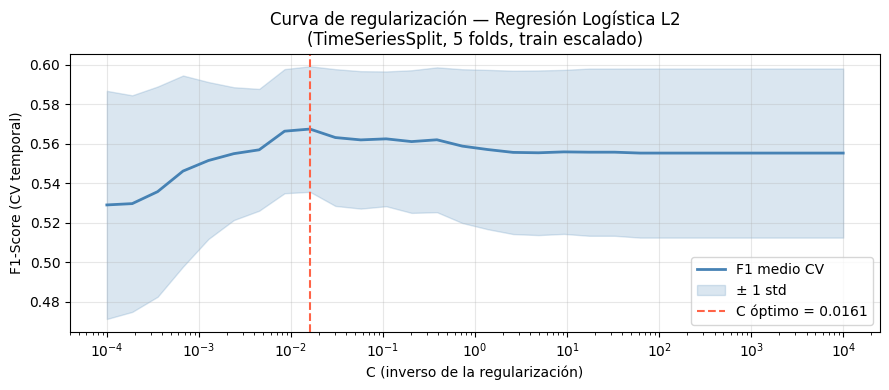

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

C_grid = np.logspace(-4, 4, 30)
tscv   = TimeSeriesSplit(n_splits=5)

f1_medias = []
f1_stds   = []

for C in C_grid:
    lr_cv = LogisticRegression(
        C=C, penalty='l2', class_weight='balanced',
        solver='lbfgs', max_iter=2000, random_state=42
    )
    scores = cross_val_score(
        lr_cv, X_train_s, y_train,
        cv=tscv, scoring='f1', n_jobs=-1
    )
    f1_medias.append(scores.mean())
    f1_stds.append(scores.std())

f1_medias = np.array(f1_medias)
f1_stds   = np.array(f1_stds)
idx_mejor = int(np.argmax(f1_medias))
C_optimo  = C_grid[idx_mejor]

print(f"C óptimo: {C_optimo:.6f}  |  F1 CV medio: {f1_medias[idx_mejor]:.4f} ± {f1_stds[idx_mejor]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(C_grid, f1_medias, color='steelblue', linewidth=2, label='F1 medio CV')
ax.fill_between(C_grid,
                f1_medias - f1_stds,
                f1_medias + f1_stds,
                alpha=0.2, color='steelblue', label='± 1 std')
ax.axvline(C_optimo, color='tomato', linestyle='--', linewidth=1.5,
           label=f'C óptimo = {C_optimo:.4f}')
ax.set_xlabel('C (inverso de la regularización)')
ax.set_ylabel('F1-Score (CV temporal)')
ax.set_title('Curva de regularización — Regresión Logística L2\n(TimeSeriesSplit, 5 folds, train escalado)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### LR: entrenamiento

In [9]:
lr_final = LogisticRegression(
    C=C_optimo,
    penalty='l2',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)
lr_final.fit(X_train_s, y_train)

y_pred_lr = lr_final.predict(X_test_s)
y_prob_lr = lr_final.predict_proba(X_test_s)[:, 1]

print(f"Modelo entrenado con C={C_optimo:.6f}, penalty=l2, class_weight=balanced")
print(f"Iteraciones hasta convergencia: {lr_final.n_iter_[0]}")
print(f"Predicciones en test — Clase 0: {(y_pred_lr==0).sum()} | Clase 1: {(y_pred_lr==1).sum()}")

Modelo entrenado con C=0.016103, penalty=l2, class_weight=balanced
Iteraciones hasta convergencia: 10
Predicciones en test — Clase 0: 509 | Clase 1: 538


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### LR: evaluación en test


  Regresión Logística  |  fase: test
  F1-Score  (PRINCIPAL) : 0.5930
  Precision             : 0.6338
  Recall                : 0.5572
  AUC-ROC               : 0.5553


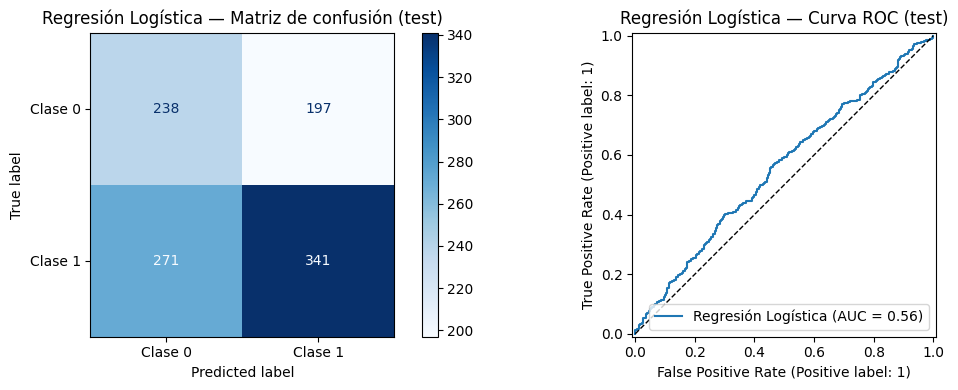

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


[LOG] 2026-06-24 23:09:32 | Regresión Logística | test | F1=0.5930 | PREC=0.6338 | REC=0.5572 | AUC=0.5553


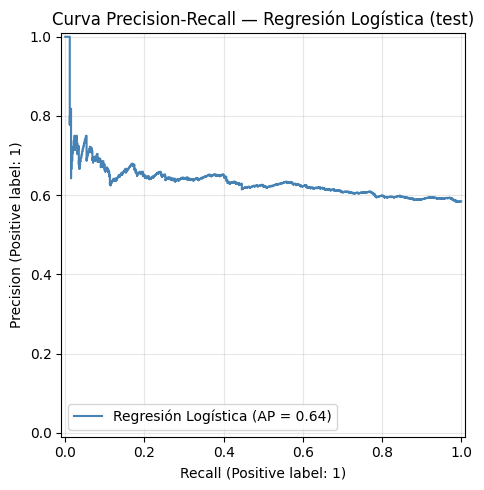

In [10]:
from sklearn.metrics import PrecisionRecallDisplay

metricas_lr = evaluar_modelo(
    nombre='Regresión Logística',
    y_true=y_test,
    y_pred=y_pred_lr,
    y_prob=y_prob_lr,
    fase='test',
    params={'C': round(C_optimo, 6), 'penalty': 'l2', 'class_weight': 'balanced'},
    notas='baseline; C óptimo por TimeSeriesSplit(5)'
)

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_lr,
    name='Regresión Logística',
    ax=ax, color='steelblue'
)
ax.set_title('Curva Precision-Recall — Regresión Logística (test)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### LR: coeficientes

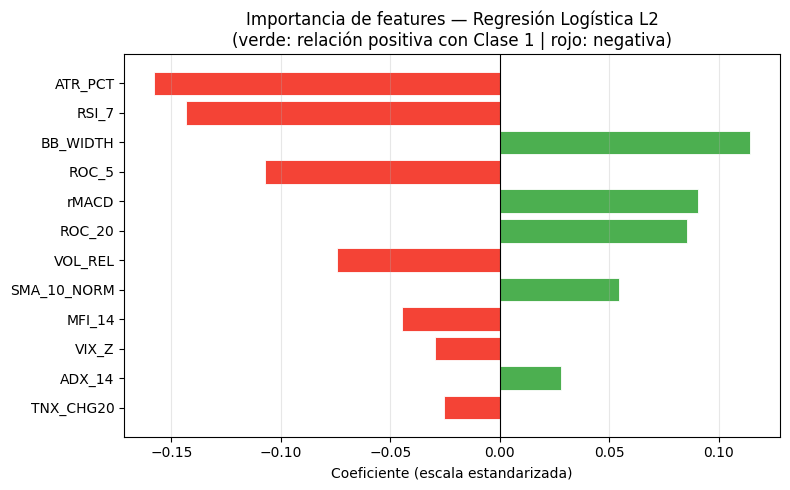

Features ordenadas por |coeficiente|:
  ATR_PCT         -0.1579
  RSI_7           -0.1433
  BB_WIDTH        +0.1144
  ROC_5           -0.1074
  rMACD           +0.0906
  ROC_20          +0.0857
  VOL_REL         -0.0743
  SMA_10_NORM     +0.0545
  MFI_14          -0.0445
  VIX_Z           -0.0297
  ADX_14          +0.0279
  TNX_CHG20       -0.0255


In [11]:
coefs      = lr_final.coef_[0]
feat_names = EFECTIVAS
orden      = np.argsort(np.abs(coefs))[::-1]
coefs_ord  = coefs[orden]
names_ord  = [feat_names[i] for i in orden]
colores    = ['#4CAF50' if c > 0 else '#f44336' for c in coefs_ord]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(names_ord[::-1], coefs_ord[::-1], color=colores[::-1],
               edgecolor='white', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (escala estandarizada)')
ax.set_title('Importancia de features — Regresión Logística L2\n(verde: relación positiva con Clase 1 | rojo: negativa)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Features ordenadas por |coeficiente|:")
for name, coef in zip(names_ord, coefs_ord):
    print(f"  {name:<15} {coef:+.4f}")

### LR: distribución de probabilidades

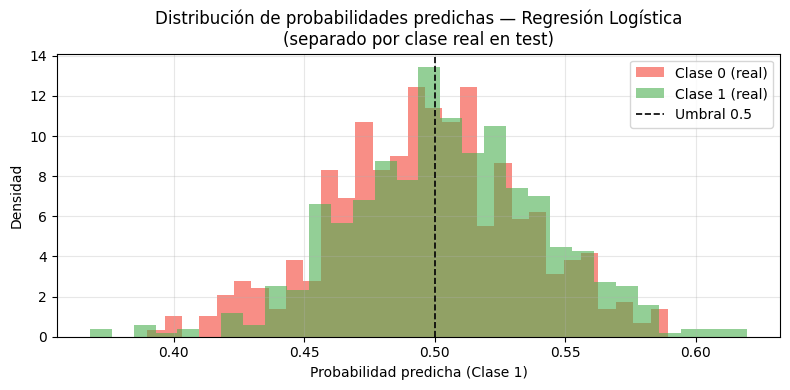

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(y_prob_lr[y_test == 0], bins=30, alpha=0.6,
        color='#f44336', label='Clase 0 (real)', density=True)
ax.hist(y_prob_lr[y_test == 1], bins=30, alpha=0.6,
        color='#4CAF50', label='Clase 1 (real)', density=True)
ax.axvline(0.5, color='black', linewidth=1.2, linestyle='--', label='Umbral 0.5')
ax.set_xlabel('Probabilidad predicha (Clase 1)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades predichas — Regresión Logística\n(separado por clase real en test)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### LR: simulación financiera


  Simulación — Regresión Logística
  Capital inicial       : $ 10,000.00
  Capital final modelo  : $ 19,854.71  (+98.5%)
  Capital final B&H     : $ 15,003.50  (+50.0%)
  Días en mercado       : 735 / 1047  (70.2%)
  ────────────────────────────────────────────────────────
  Nº operaciones        : 147
  Win rate              : 62.6%
  Retorno medio/op      : +0.50%
  ────────────────────────────────────────────────────────
  Máx. drawdown modelo  : 12.05%
  Máx. drawdown B&H     : 25.43%


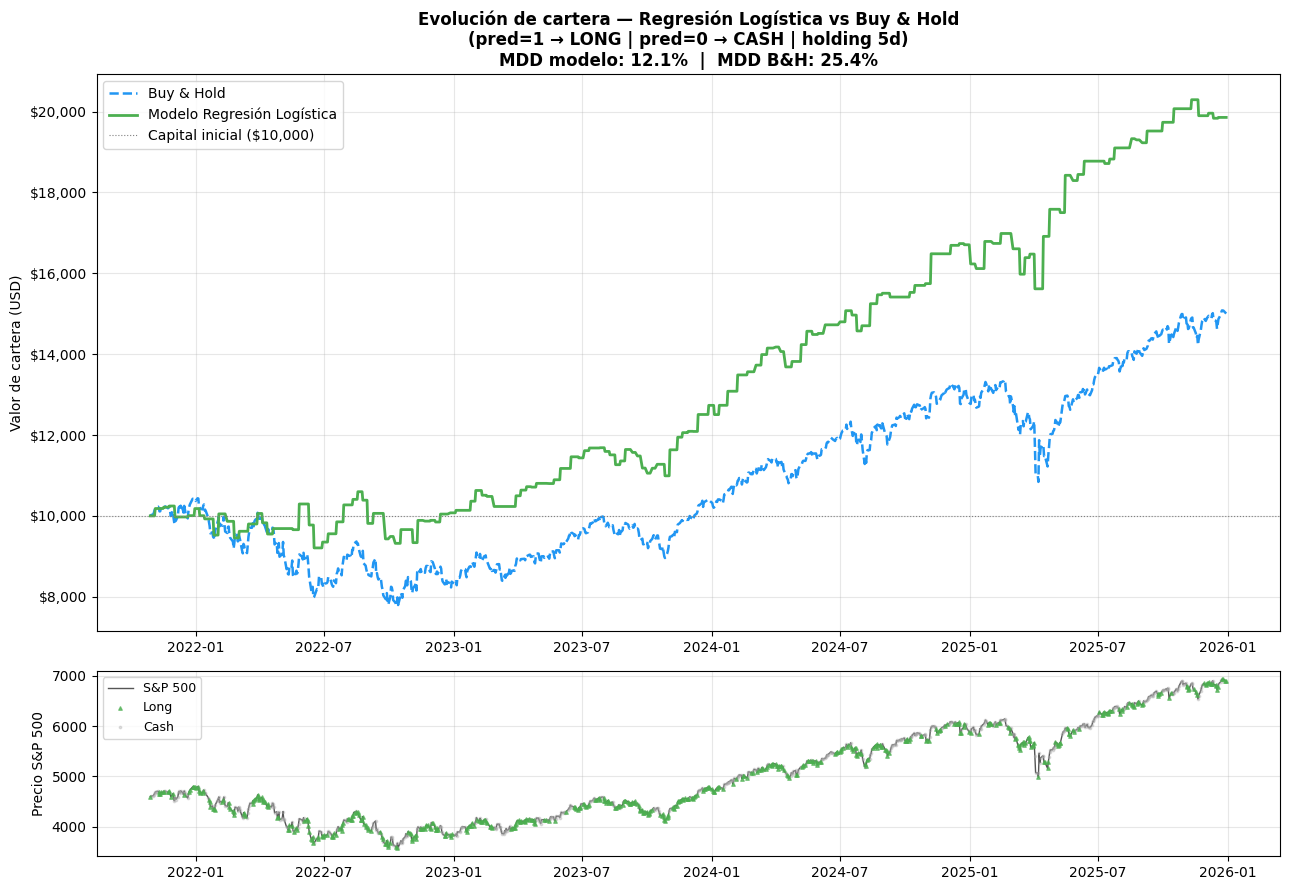

[LOG] 2026-06-24 23:09:32 | Regresión Logística | simulacion | F1=0.5930 | PREC=0.6338 | REC=0.5572 | AUC=0.5553| RET_MOD=+98.55% | RET_BH=+50.04%

Resultados registrados en resultados_comparativa['Regresión Logística']


In [13]:
resultados_comparativa = {}

close_test = test['CLOSE']

sim_lr = simular_cartera(
    nombre='Regresión Logística',
    y_pred=y_pred_lr,
    close_test=close_test,
    capital_inicial=CAPITAL_INICIAL,
    gap_dias=GAP_DIAS
)

resultados_comparativa['Regresión Logística'] = sim_lr

log_resultado(
    modelo='Regresión Logística',
    fase='simulacion',
    f1_score=metricas_lr['f1'],
    precision=metricas_lr['precision'],
    recall=metricas_lr['recall'],
    auc_roc=metricas_lr['auc'],
    rentabilidad_modelo=sim_lr['retorno_modelo_%'],
    rentabilidad_bh=sim_lr['retorno_bh_%'],
    params={'C': round(C_optimo, 6), 'penalty': 'l2', 'class_weight': 'balanced'},
    notas='simulacion financiera long/cash vs buy&hold'
)

print("\nResultados registrados en resultados_comparativa['Regresión Logística']")

### RF: búsqueda de hiperparámetros

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn


Mejores parámetros RF (espacio regularizado):
  n_estimators           300
  min_samples_split      8
  min_samples_leaf       2
  max_features           sqrt
  max_depth              15
  criterion              gini
  bootstrap              True

F1-Score CV (mejor): 0.5827


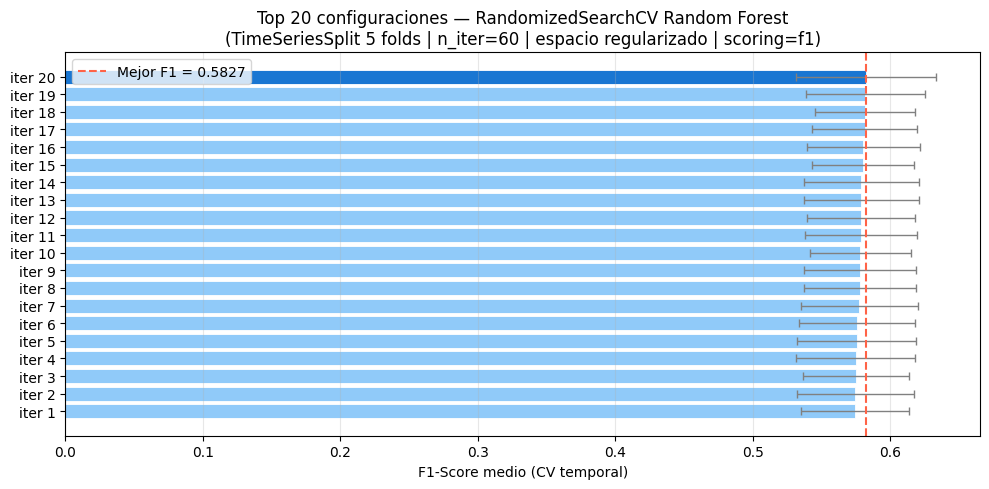

In [14]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

param_dist = {
    'n_estimators'     : [200, 300, 500, 800],
    'max_depth'        : [4, 6, 8, 10, 15],
    'min_samples_leaf' : [2, 4, 6, 8, 12],
    'min_samples_split': [4, 6, 8, 10],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap'        : [True],
    'criterion'        : ['gini', 'entropy'],
}

tscv_rf = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=60,
    scoring='f1',
    cv=tscv_rf,
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=False,
)

rf_search.fit(X_train_s, y_train)

mejores_params_rf = rf_search.best_params_
f1_cv_rf          = rf_search.best_score_

print(f"\nMejores parámetros RF (espacio regularizado):")
for k, v in mejores_params_rf.items():
    print(f"  {k:<22} {v}")
print(f"\nF1-Score CV (mejor): {f1_cv_rf:.4f}")

cv_results = pd.DataFrame(rf_search.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False).head(20).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
colores_bar = ['#1976D2' if i == 0 else '#90CAF9' for i in range(len(cv_results))]
ax.barh(
    [f"iter {i+1}" for i in range(len(cv_results))],
    cv_results['mean_test_score'].values[::-1],
    xerr=cv_results['std_test_score'].values[::-1],
    color=colores_bar[::-1],
    edgecolor='white', linewidth=0.6,
    error_kw={'elinewidth': 1, 'ecolor': 'grey', 'capsize': 3}
)
ax.axvline(f1_cv_rf, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Mejor F1 = {f1_cv_rf:.4f}')
ax.set_xlabel('F1-Score medio (CV temporal)')
ax.set_title('Top 20 configuraciones — RandomizedSearchCV Random Forest\n'
             '(TimeSeriesSplit 5 folds | n_iter=60 | espacio regularizado | scoring=f1)')
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### RF: entrenamiento

In [15]:
rf_final = rf_search.best_estimator_

y_pred_rf = rf_final.predict(X_test_s)
y_prob_rf = rf_final.predict_proba(X_test_s)[:, 1]

print("Modelo: Random Forest (best_estimator_ de RandomizedSearchCV)")
print(f"\nParámetros finales:")
for k, v in mejores_params_rf.items():
    print(f"  {k:<22} {v}")
print(f"\nÁrboles en el ensemble : {rf_final.n_estimators}")
print(f"Predicciones en test   — Clase 0: {(y_pred_rf == 0).sum()} | Clase 1: {(y_pred_rf == 1).sum()}")

Modelo: Random Forest (best_estimator_ de RandomizedSearchCV)

Parámetros finales:
  n_estimators           300
  min_samples_split      8
  min_samples_leaf       2
  max_features           sqrt
  max_depth              15
  criterion              gini
  bootstrap              True

Árboles en el ensemble : 300
Predicciones en test   — Clase 0: 399 | Clase 1: 648


### RF: evaluación en test


  Random Forest  |  fase: test
  F1-Score  (PRINCIPAL) : 0.6365
  Precision             : 0.6188
  Recall                : 0.6552
  AUC-ROC               : 0.5655


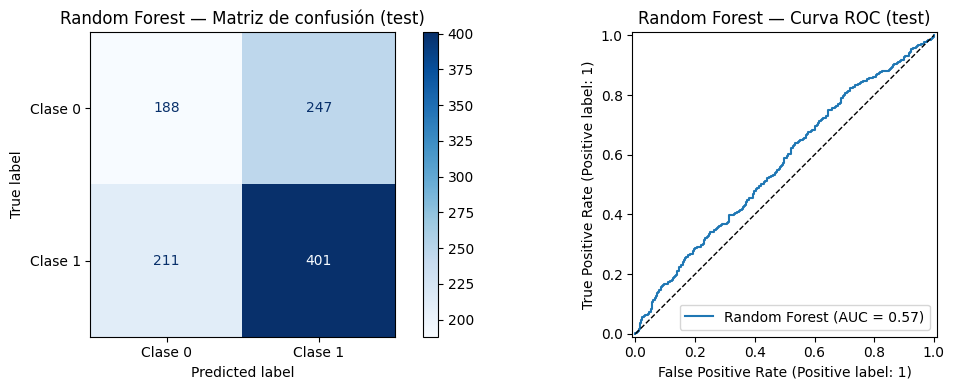

[LOG] 2026-06-24 23:10:38 | Random Forest | test | F1=0.6365 | PREC=0.6188 | REC=0.6552 | AUC=0.5655


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


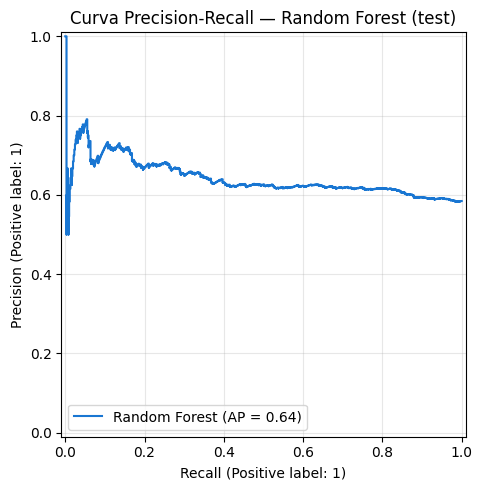

In [16]:
from sklearn.metrics import PrecisionRecallDisplay

metricas_rf = evaluar_modelo(
    nombre='Random Forest',
    y_true=y_test,
    y_pred=y_pred_rf,
    y_prob=y_prob_rf,
    fase='test',
    params=mejores_params_rf,
    notas='RandomizedSearchCV 40 iter; TimeSeriesSplit(5); class_weight=balanced'
)

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_rf,
    name='Random Forest',
    ax=ax, color='#1976D2'
)
ax.set_title('Curva Precision-Recall — Random Forest (test)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### RF: importancia de variables

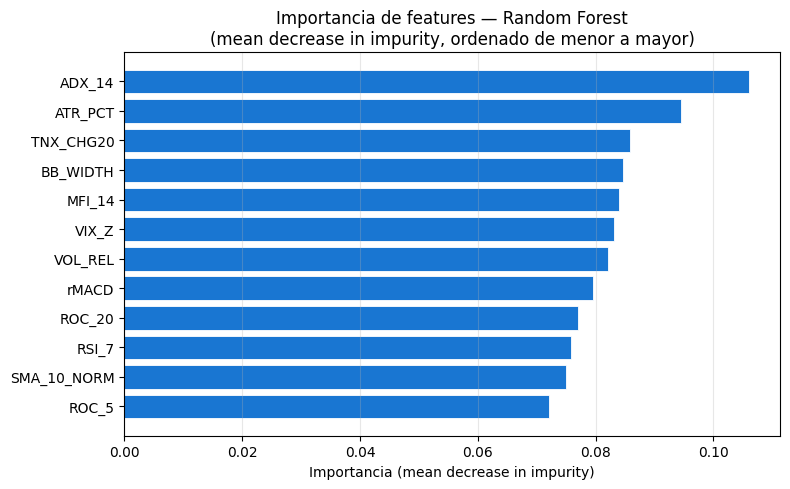

Features ordenadas por importancia (mayor → menor):
  ADX_14          0.1060
  ATR_PCT         0.0945
  TNX_CHG20       0.0858
  BB_WIDTH        0.0847
  MFI_14          0.0840
  VIX_Z           0.0831
  VOL_REL         0.0822
  rMACD           0.0796
  ROC_20          0.0770
  RSI_7           0.0759
  SMA_10_NORM     0.0750
  ROC_5           0.0721


In [17]:
importancias  = rf_final.feature_importances_
orden_rf      = np.argsort(importancias)
names_ord_rf  = [EFECTIVAS[i] for i in orden_rf]
imp_ord_rf    = importancias[orden_rf]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(names_ord_rf, imp_ord_rf,
        color='#1976D2', edgecolor='white', linewidth=0.6)
ax.set_xlabel('Importancia (mean decrease in impurity)')
ax.set_title('Importancia de features — Random Forest\n(mean decrease in impurity, ordenado de menor a mayor)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Features ordenadas por importancia (mayor → menor):")
for name, imp in zip(names_ord_rf[::-1], imp_ord_rf[::-1]):
    print(f"  {name:<15} {imp:.4f}")

### RF: distribución de probabilidades

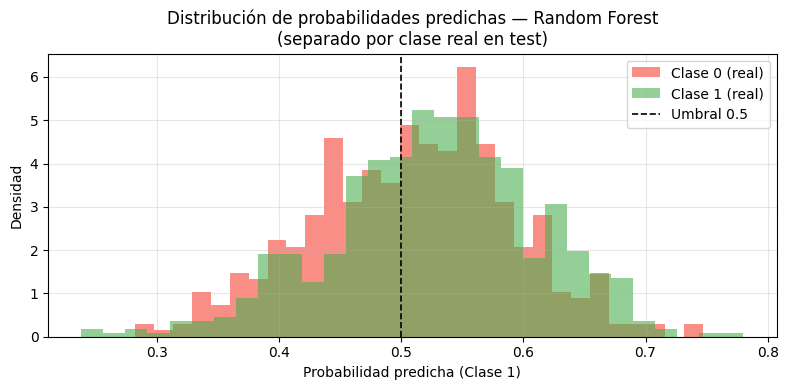

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(y_prob_rf[y_test == 0], bins=30, alpha=0.6,
        color='#f44336', label='Clase 0 (real)', density=True)
ax.hist(y_prob_rf[y_test == 1], bins=30, alpha=0.6,
        color='#4CAF50', label='Clase 1 (real)', density=True)
ax.axvline(0.5, color='black', linewidth=1.2, linestyle='--', label='Umbral 0.5')
ax.set_xlabel('Probabilidad predicha (Clase 1)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades predichas — Random Forest\n(separado por clase real en test)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### RF: simulación financiera


  Simulación — Random Forest
  Capital inicial       : $ 10,000.00
  Capital final modelo  : $ 16,304.22  (+63.0%)
  Capital final B&H     : $ 15,003.50  (+50.0%)
  Días en mercado       : 830 / 1047  (79.3%)
  ────────────────────────────────────────────────────────
  Nº operaciones        : 166
  Win rate              : 61.4%
  Retorno medio/op      : +0.32%
  ────────────────────────────────────────────────────────
  Máx. drawdown modelo  : 17.53%
  Máx. drawdown B&H     : 25.43%


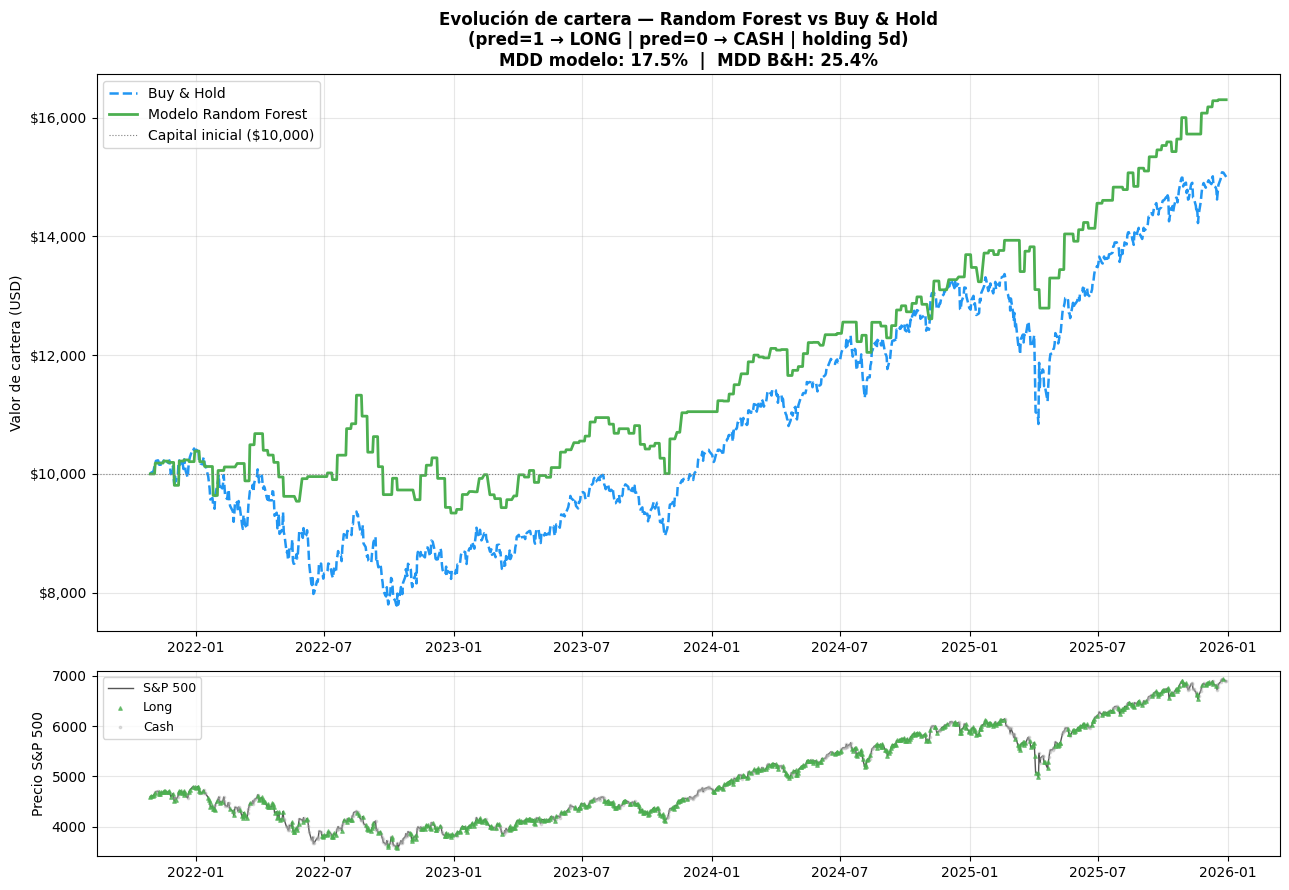

[LOG] 2026-06-24 23:10:39 | Random Forest | simulacion | F1=0.6365 | PREC=0.6188 | REC=0.6552 | AUC=0.5655| RET_MOD=+63.04% | RET_BH=+50.04%

Resultados registrados en resultados_comparativa['Random Forest']


In [19]:
sim_rf = simular_cartera(
    nombre='Random Forest',
    y_pred=y_pred_rf,
    close_test=close_test,
    capital_inicial=CAPITAL_INICIAL,
    gap_dias=GAP_DIAS
)

resultados_comparativa['Random Forest'] = sim_rf

log_resultado(
    modelo='Random Forest',
    fase='simulacion',
    f1_score=metricas_rf['f1'],
    precision=metricas_rf['precision'],
    recall=metricas_rf['recall'],
    auc_roc=metricas_rf['auc'],
    rentabilidad_modelo=sim_rf['retorno_modelo_%'],
    rentabilidad_bh=sim_rf['retorno_bh_%'],
    params=mejores_params_rf,
    notas='simulacion financiera long/cash vs buy&hold'
)

print("\nResultados registrados en resultados_comparativa['Random Forest']")

### Comparativa LR vs RF: retornos

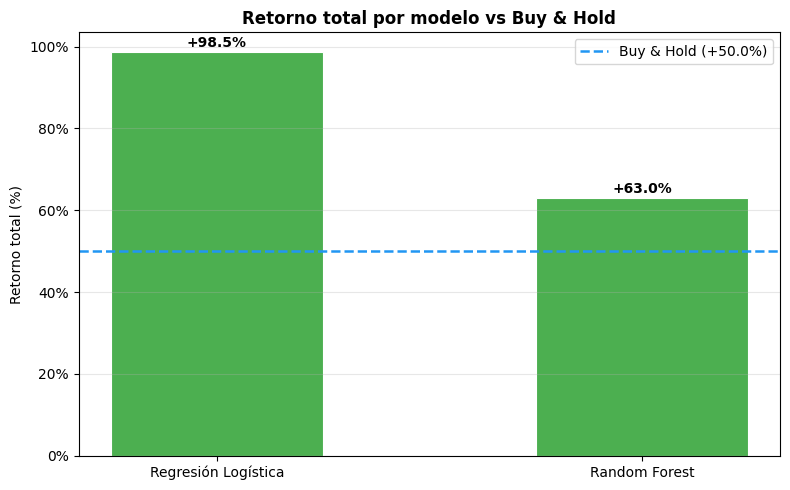


Modelo                 Ret.mod   Ret.B&H     MDD  % invert       Capital  N ops    Win%  R.med/op
-------------------------------------------------------------------------------------------------
Regresión Logística      98.5%     50.0%   12.1%     70.2%$       19,855    147   62.6%    +0.50%
Random Forest            63.0%     50.0%   17.5%     79.3%$       16,304    166   61.5%    +0.32%


In [20]:
comparar_modelos(resultados_comparativa)

### Comparativa LR vs RF: métricas

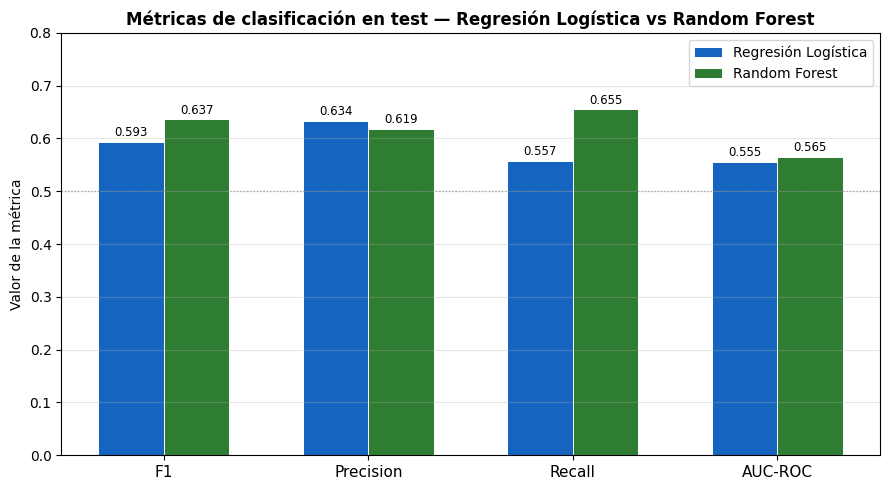


Resumen métricas de clasificación:
Métrica        Reg. Logística   Random Forest
---------------------------------------------
F1                     0.5930          0.6365
Precision              0.6338          0.6188
Recall                 0.5572          0.6552
AUC-ROC                0.5553          0.5655


In [21]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

metricas_comp = {
    'Regresión Logística': {
        'F1':        f1_score(y_test, y_pred_lr, zero_division=0),
        'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_lr, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_lr),
    },
    'Random Forest': {
        'F1':        f1_score(y_test, y_pred_rf, zero_division=0),
        'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_rf, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_rf),
    },
}

etiquetas  = ['F1', 'Precision', 'Recall', 'AUC-ROC']
valores_lr = [metricas_comp['Regresión Logística'][m] for m in etiquetas]
valores_rf = [metricas_comp['Random Forest'][m]       for m in etiquetas]

x      = np.arange(len(etiquetas))
ancho  = 0.32

fig, ax = plt.subplots(figsize=(9, 5))

barras_lr = ax.bar(x - ancho / 2, valores_lr, ancho,
                   color='#1565C0', label='Regresión Logística',
                   edgecolor='white', linewidth=0.7)
barras_rf = ax.bar(x + ancho / 2, valores_rf, ancho,
                   color='#2E7D32', label='Random Forest',
                   edgecolor='white', linewidth=0.7)

for bars in (barras_lr, barras_rf):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha='center', va='bottom', fontsize=8.5)

ax.axhline(0.5, color='grey', linewidth=0.9, linestyle=':', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim(0, 0.80)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Métricas de clasificación en test — Regresión Logística vs Random Forest',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nResumen métricas de clasificación:")
print(f"{'Métrica':<12} {'Reg. Logística':>16} {'Random Forest':>15}")
print("-" * 45)
for m in etiquetas:
    lr_v = metricas_comp['Regresión Logística'][m]
    rf_v = metricas_comp['Random Forest'][m]
    print(f"{m:<12} {lr_v:>16.4f} {rf_v:>15.4f}")

### Comparativa LR vs RF: tabla financiera

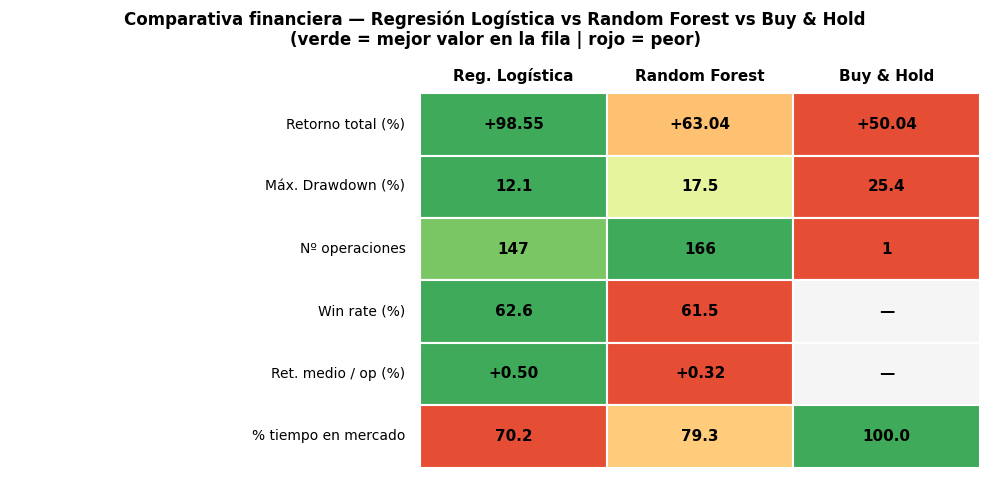

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

lr  = resultados_comparativa['Regresión Logística']
rf  = resultados_comparativa['Random Forest']
bh_ret   = lr['retorno_bh_%']
bh_mdd   = lr['max_drawdown_bh_%']

filas = [
    'Retorno total (%)',
    'Máx. Drawdown (%)',
    'Nº operaciones',
    'Win rate (%)',
    'Ret. medio / op (%)',
    '% tiempo en mercado',
]

datos = {
    'Reg. Logística': [
        lr['retorno_modelo_%'],
        lr['max_drawdown_%'],
        lr['n_operaciones'],
        lr['win_rate_%'],
        lr['avg_ret_op_%'],
        lr['pct_tiempo_mercado_%'],
    ],
    'Random Forest': [
        rf['retorno_modelo_%'],
        rf['max_drawdown_%'],
        rf['n_operaciones'],
        rf['win_rate_%'],
        rf['avg_ret_op_%'],
        rf['pct_tiempo_mercado_%'],
    ],
    'Buy & Hold': [
        bh_ret,
        bh_mdd,
        1,
        '—',
        '—',
        100.0,
    ],
}

columnas = list(datos.keys())
n_filas  = len(filas)
n_cols   = len(columnas)

mat_num = np.full((n_filas, n_cols), np.nan)
for j, col in enumerate(columnas):
    for i, val in enumerate(datos[col]):
        try:
            mat_num[i, j] = float(val)
        except (ValueError, TypeError):
            pass

mejor_es_menor = {0: False, 1: True, 2: False, 3: False, 4: False, 5: False}

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_filas)
ax.axis('off')

cmap_verde = plt.cm.RdYlGn
cmap_rojo  = plt.cm.RdYlGn_r

for i in range(n_filas):
    fila_vals = mat_num[i, :]
    validos   = fila_vals[~np.isnan(fila_vals)]
    if len(validos) < 2:
        vmin, vmax = 0, 1
    else:
        vmin, vmax = validos.min(), validos.max()
        if vmin == vmax:
            vmin -= 0.001

    cmap = cmap_rojo if mejor_es_menor[i] else cmap_verde

    for j in range(n_cols):
        val   = datos[columnas[j]][i]
        num   = mat_num[i, j]
        if not np.isnan(num) and vmax > vmin:
            norm_val = (num - vmin) / (vmax - vmin)
            color    = cmap(0.15 + norm_val * 0.70)
        else:
            color = '#f5f5f5'

        rect = plt.Rectangle([j, n_filas - 1 - i], 1, 1,
                              facecolor=color, edgecolor='white', linewidth=1.5)
        ax.add_patch(rect)

        if isinstance(val, float):
            texto = f"{val:+.2f}" if i in (0, 4) else f"{val:.1f}"
        else:
            texto = str(val)

        ax.text(j + 0.5, n_filas - 0.5 - i, texto,
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='black')

for j, col in enumerate(columnas):
    ax.text(j + 0.5, n_filas + 0.15, col,
            ha='center', va='bottom', fontsize=11, fontweight='bold')

for i, fila in enumerate(filas):
    ax.text(-0.08, n_filas - 0.5 - i, fila,
            ha='right', va='center', fontsize=10)

ax.set_xlim(-2.2, n_cols)
ax.set_ylim(-0.2, n_filas + 0.5)

ax.set_title('Comparativa financiera — Regresión Logística vs Random Forest vs Buy & Hold\n'
             '(verde = mejor valor en la fila | rojo = peor)',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

### LSTM: secuencias y búsqueda de hiperparámetros

Búsqueda aleatoria — 8 configuraciones; selección por AUC (media de 2 semillas)

  cfg00: L=10 h=16 nl=2 do=0.2 lr=0.0005 bs=64 wd=0.001  ->  AUC_val=0.5939  F1_val=0.6413
  cfg01: L=10 h=16 nl=1 do=0.2 lr=0.001 bs=64 wd=0.0001  ->  AUC_val=0.5263  F1_val=0.5896
  cfg02: L=15 h=16 nl=2 do=0.3 lr=0.001 bs=64 wd=0.001  ->  AUC_val=0.5296  F1_val=0.5492
  cfg03: L=15 h=16 nl=2 do=0.2 lr=0.0005 bs=64 wd=0.0001  ->  AUC_val=0.5163  F1_val=0.5274
  cfg04: L=20 h=16 nl=1 do=0.3 lr=0.0001 bs=64 wd=0.0001  ->  AUC_val=0.4937  F1_val=0.7570
  cfg05: L=15 h=32 nl=2 do=0.3 lr=0.0005 bs=64 wd=0.001  ->  AUC_val=0.5465  F1_val=0.5631
  cfg06: L=10 h=16 nl=1 do=0.3 lr=0.001 bs=32 wd=0.001  ->  AUC_val=0.5605  F1_val=0.6297
  cfg07: L=15 h=32 nl=2 do=0.3 lr=0.0001 bs=64 wd=0.001  ->  AUC_val=0.5227  F1_val=0.3888

Mejor configuración (por AUC): L=10, hidden=16, layers=2, dropout=0.2, lr=0.0005, bs=64, weight_decay=0.001  |  AUC val=0.5939, F1 val=0.6413


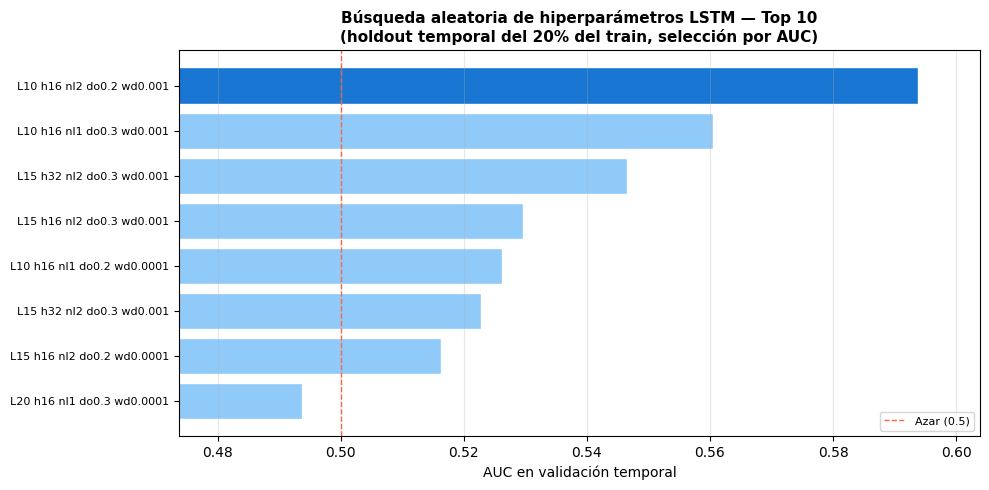

In [23]:
# construcción de secuencias y búsqueda aleatoria de hiperparámetros
import torch, torch.nn as nn, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import f1_score, roc_auc_score
torch.manual_seed(42)
np.random.seed(42)
DEVICE = 'cpu'

def make_seq(X, y, L):
    xs = [X[i-L+1:i+1] for i in range(L-1, len(X))]
    ys = [y[i]          for i in range(L-1, len(X))]
    return np.asarray(xs, dtype='float32'), np.asarray(ys, dtype='float32')

class LSTMClassifier(nn.Module):
    def __init__(self, n_feat, hidden, layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

def entrenar_lstm(Xs, ys, Xv, yv, hidden, layers, dropout, lr, bs, wd,
                  seed, max_ep=300, paciencia=30, min_ep=25):
    torch.manual_seed(seed)
    model = LSTMClassifier(Xs.shape[2], hidden, layers, dropout).to(DEVICE)
    pos = ys.sum()
    neg = len(ys) - pos
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/max(pos,1)], dtype=torch.float32))
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    Xs_t, ys_t, Xv_t = torch.tensor(Xs), torch.tensor(ys), torch.tensor(Xv)
    n = len(Xs)
    mejor = -1
    estado = None
    mejor_ep = 0
    espera = 0
    hist = []
    for ep in range(max_ep):
        model.train()
        perm = torch.randperm(n)
        tot = 0.0
        for j in range(0, n, bs):
            idx = perm[j:j+bs]
            opt.zero_grad()
            loss = crit(model(Xs_t[idx]), ys_t[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            pv = torch.sigmoid(model(Xv_t)).numpy()
        auc = roc_auc_score(yv, pv)
        f1 = f1_score(yv, (pv >= 0.5).astype(int), zero_division=0)
        hist.append((tot/n, f1, auc))
        if auc > mejor + 1e-4:
            mejor = auc
            estado = {k: v.clone() for k, v in model.state_dict().items()}
            mejor_ep = ep + 1
            espera = 0
        elif ep >= min_ep:
            espera += 1
        if espera >= paciencia:
            break
    model.load_state_dict(estado)
    with torch.no_grad():
        pv = torch.sigmoid(model(Xv_t)).numpy()
    return (model, f1_score(yv, (pv >= 0.5).astype(int), zero_division=0),
            roc_auc_score(yv, pv), mejor_ep, hist)

n_tr = len(X_train_s)
n_val = int(n_tr * 0.2)
Xtf, ytf = X_train_s[:n_tr - n_val - GAP_DIAS], y_train[:n_tr - n_val - GAP_DIAS]
Xvl, yvl = X_train_s[n_tr - n_val:],            y_train[n_tr - n_val:]

espacio = dict(L=[10, 15, 20], hidden=[16, 32], layers=[1, 2], dropout=[0.2, 0.3], lr=[1e-4, 5e-4, 1e-3], bs=[32, 64], wd=[1e-4, 1e-3])
N_CONFIG = 8
SEEDS_SEL = [0, 1]
rng = np.random.default_rng(11)
resultados_lstm = []
print(f"Búsqueda aleatoria — {N_CONFIG} configuraciones; selección por AUC (media de {len(SEEDS_SEL)} semillas)\n")
for c in range(N_CONFIG):
    cfg = dict(L=int(rng.choice(espacio['L'])), hidden=int(rng.choice(espacio['hidden'])),
               layers=int(rng.choice(espacio['layers'])), dropout=float(rng.choice(espacio['dropout'])),
               lr=float(rng.choice(espacio['lr'])), bs=int(rng.choice(espacio['bs'])), wd=float(rng.choice(espacio['wd'])))
    Xs, ys = make_seq(Xtf, ytf, cfg['L'])
    Xv, yv = make_seq(Xvl, yvl, cfg['L'])
    aucs, f1s, eps = [], [], []
    for sd in SEEDS_SEL:
        _, f1v, aucv, ep, _ = entrenar_lstm(Xs, ys, Xv, yv, cfg['hidden'], cfg['layers'],
                                             cfg['dropout'], cfg['lr'], cfg['bs'], cfg['wd'], sd)
        aucs.append(aucv)
        f1s.append(f1v)
        eps.append(ep)
    resultados_lstm.append({**cfg, 'val_auc': np.mean(aucs), 'val_f1': np.mean(f1s), 'best_ep': int(np.median(eps))})
    print(f"  cfg{c:02d}: L={cfg['L']:>2} h={cfg['hidden']:>2} nl={cfg['layers']} do={cfg['dropout']} "
          f"lr={cfg['lr']} bs={cfg['bs']} wd={cfg['wd']}  ->  AUC_val={np.mean(aucs):.4f}  F1_val={np.mean(f1s):.4f}")

df_lstm = pd.DataFrame(resultados_lstm).sort_values('val_auc', ascending=False).reset_index(drop=True)
best_lstm = df_lstm.iloc[0].to_dict()
print(f"\nMejor configuración (por AUC): L={int(best_lstm['L'])}, hidden={int(best_lstm['hidden'])}, "
      f"layers={int(best_lstm['layers'])}, dropout={best_lstm['dropout']}, lr={best_lstm['lr']}, "
      f"bs={int(best_lstm['bs'])}, weight_decay={best_lstm['wd']}  |  AUC val={best_lstm['val_auc']:.4f}, F1 val={best_lstm['val_f1']:.4f}")

top = df_lstm.head(10).iloc[::-1]
etiq = [f"L{int(r.L)} h{int(r.hidden)} nl{int(r.layers)} do{r.dropout} wd{r.wd}" for r in top.itertuples()]
colores = ['#1976D2' if i == len(top)-1 else '#90CAF9' for i in range(len(top))]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top)), top['val_auc'], color=colores, edgecolor='white')
ax.axvline(0.5, color='tomato', ls='--', lw=1, label='Azar (0.5)')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(etiq, fontsize=8)
ax.set_xlabel('AUC en validación temporal')
ax.set_title('Búsqueda aleatoria de hiperparámetros LSTM — Top 10\n'
             '(holdout temporal del 20% del train, selección por AUC)', fontsize=11, fontweight='bold')
ax.set_xlim(min(top['val_auc'].min()-0.02, 0.49), top['val_auc'].max()+0.01)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### LSTM: entrenamiento (ensemble)

Ensemble de 3 modelos LSTM entrenados sobre 4172 secuencias de longitud 10 (156 épocas c/u).


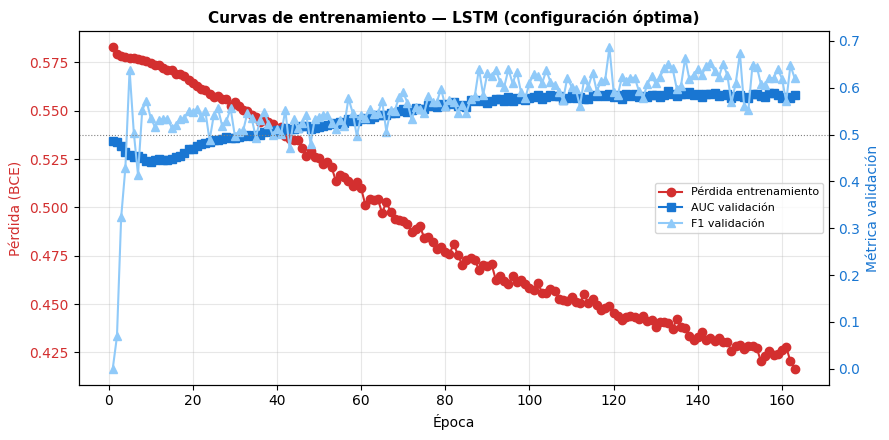

In [24]:
L  = int(best_lstm['L'])
H  = int(best_lstm['hidden'])
NL = int(best_lstm['layers'])
DO = float(best_lstm['dropout'])
LR = float(best_lstm['lr'])
BS = int(best_lstm['bs'])
WD = float(best_lstm['wd'])
EP = int(best_lstm['best_ep'])
SEEDS_ENS = [0, 1, 2]

Xs, ys = make_seq(Xtf, ytf, L)
Xv, yv = make_seq(Xvl, yvl, L)
_, _, _, _, hist = entrenar_lstm(Xs, ys, Xv, yv, H, NL, DO, LR, BS, WD, 0)

Xf, yf = make_seq(X_train_s, y_train, L)
pos = yf.sum()
neg = len(yf) - pos
lstm_ensemble = []
for sd in SEEDS_ENS:
    torch.manual_seed(sd)
    model = LSTMClassifier(Xf.shape[2], H, NL, DO).to(DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/max(pos,1)], dtype=torch.float32))
    opt  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    Xf_t, yf_t = torch.tensor(Xf), torch.tensor(yf)
    nf = len(Xf)
    for ep in range(EP):
        model.train()
        perm = torch.randperm(nf)
        for j in range(0, nf, BS):
            idx = perm[j:j+BS]
            opt.zero_grad()
            loss = crit(model(Xf_t[idx]), yf_t[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    model.eval()
    lstm_ensemble.append(model)
print(f"Ensemble de {len(lstm_ensemble)} modelos LSTM entrenados sobre {nf} secuencias de longitud {L} ({EP} épocas c/u).")

ep_range = range(1, len(hist)+1)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(ep_range, [h[0] for h in hist], '-o', color='#d32f2f', label='Pérdida entrenamiento')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida (BCE)', color='#d32f2f')
ax1.tick_params(axis='y', labelcolor='#d32f2f')
ax2 = ax1.twinx()
ax2.plot(ep_range, [h[2] for h in hist], '-s', color='#1976D2', label='AUC validación')
ax2.plot(ep_range, [h[1] for h in hist], '-^', color='#90CAF9', label='F1 validación')
ax2.axhline(0.5, color='grey', ls=':', lw=0.8)
ax2.set_ylabel('Métrica validación', color='#1976D2')
ax2.tick_params(axis='y', labelcolor='#1976D2')
ax1.set_title('Curvas de entrenamiento — LSTM (configuración óptima)', fontsize=11, fontweight='bold')
ax1.grid(alpha=0.3)
h1,l1=ax1.get_legend_handles_labels()
h2,l2=ax2.get_legend_handles_labels()
ax1.legend(h1+h2,l1+l2,fontsize=8,loc='center right')
plt.tight_layout() 
plt.show()

### LSTM: evaluación en test


  LSTM  |  fase: test
  F1-Score  (PRINCIPAL) : 0.5656
  Precision             : 0.6080
  Recall                : 0.5288
  AUC-ROC               : 0.5295


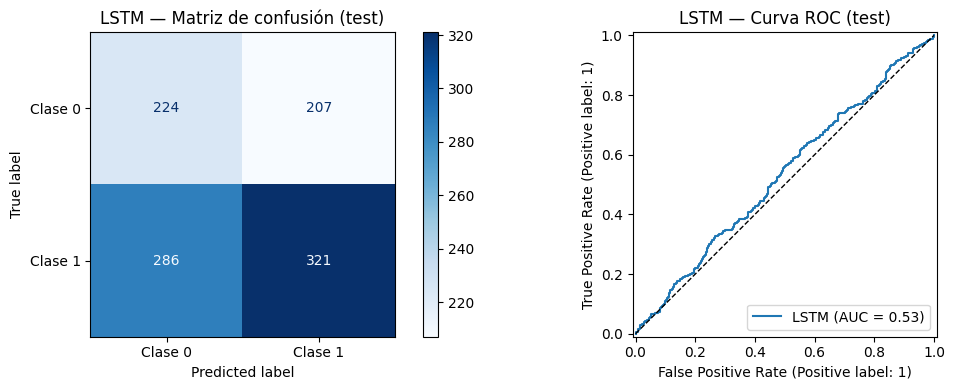

[LOG] 2026-06-24 23:17:16 | LSTM | test | F1=0.5656 | PREC=0.6080 | REC=0.5288 | AUC=0.5295


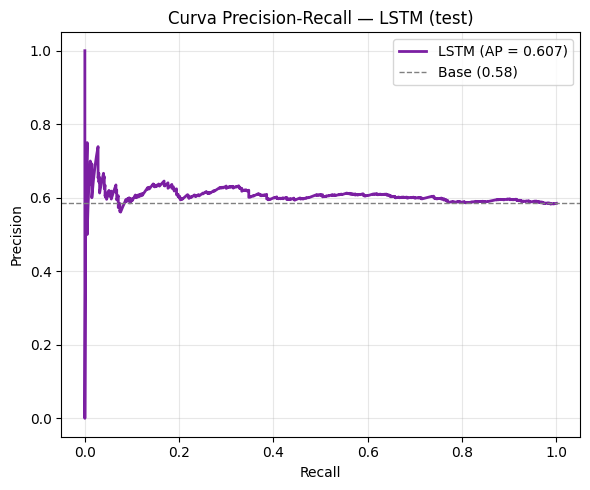

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score
Xtes, ytes = make_seq(X_test_s, y_test, L)
Xtes_t = torch.tensor(Xtes)
with torch.no_grad():
    y_prob_lstm = np.mean([torch.sigmoid(m(Xtes_t)).numpy() for m in lstm_ensemble], axis=0)
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)
y_test_lstm = ytes.astype(int)

met_lstm = evaluar_modelo('LSTM', y_test_lstm, y_pred_lstm, y_prob_lstm, fase='test',
                          params={k: best_lstm[k] for k in ['L','hidden','layers','dropout','lr','bs','wd']},
                          notas='PyTorch nn.LSTM regularizada (L2+dropout+clip); seleccion por AUC; ensemble 3 semillas; umbral 0.5')

prec, rec, _ = precision_recall_curve(y_test_lstm, y_prob_lstm)
ap = average_precision_score(y_test_lstm, y_prob_lstm)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec, prec, color='#7B1FA2', lw=2, label=f'LSTM (AP = {ap:.3f})')
ax.axhline(y_test_lstm.mean(), color='grey', ls='--', lw=1, label=f'Base ({y_test_lstm.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — LSTM (test)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### LSTM: distribución de probabilidades

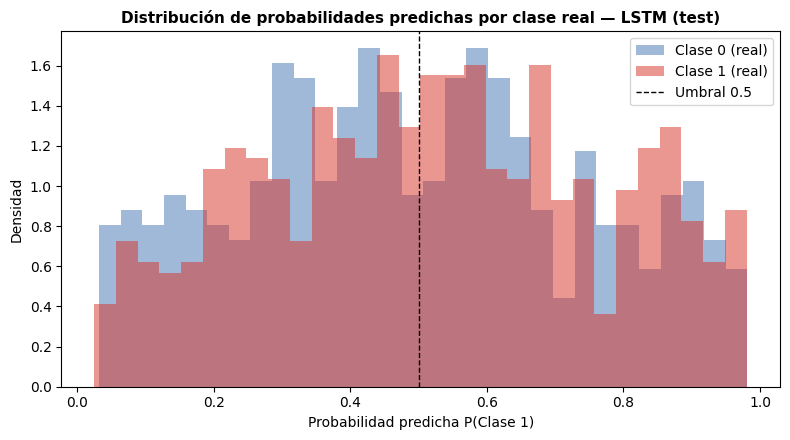

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(y_prob_lstm[y_test_lstm == 0], bins=30, alpha=0.5, color='#4575b4', density=True, label='Clase 0 (real)')
ax.hist(y_prob_lstm[y_test_lstm == 1], bins=30, alpha=0.5, color='#d73027', density=True, label='Clase 1 (real)')
ax.axvline(0.5, color='black', ls='--', lw=1, label='Umbral 0.5')
ax.set_xlabel('Probabilidad predicha P(Clase 1)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades predichas por clase real — LSTM (test)', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### LSTM: simulación financiera


  Simulación — LSTM
  Capital inicial       : $ 10,000.00
  Capital final modelo  : $ 17,277.18  (+72.8%)
  Capital final B&H     : $ 14,841.12  (+48.4%)
  Días en mercado       : 640 / 1038  (61.7%)
  ────────────────────────────────────────────────────────
  Nº operaciones        : 128
  Win rate              : 63.3%
  Retorno medio/op      : +0.46%
  ────────────────────────────────────────────────────────
  Máx. drawdown modelo  : 12.96%
  Máx. drawdown B&H     : 25.43%


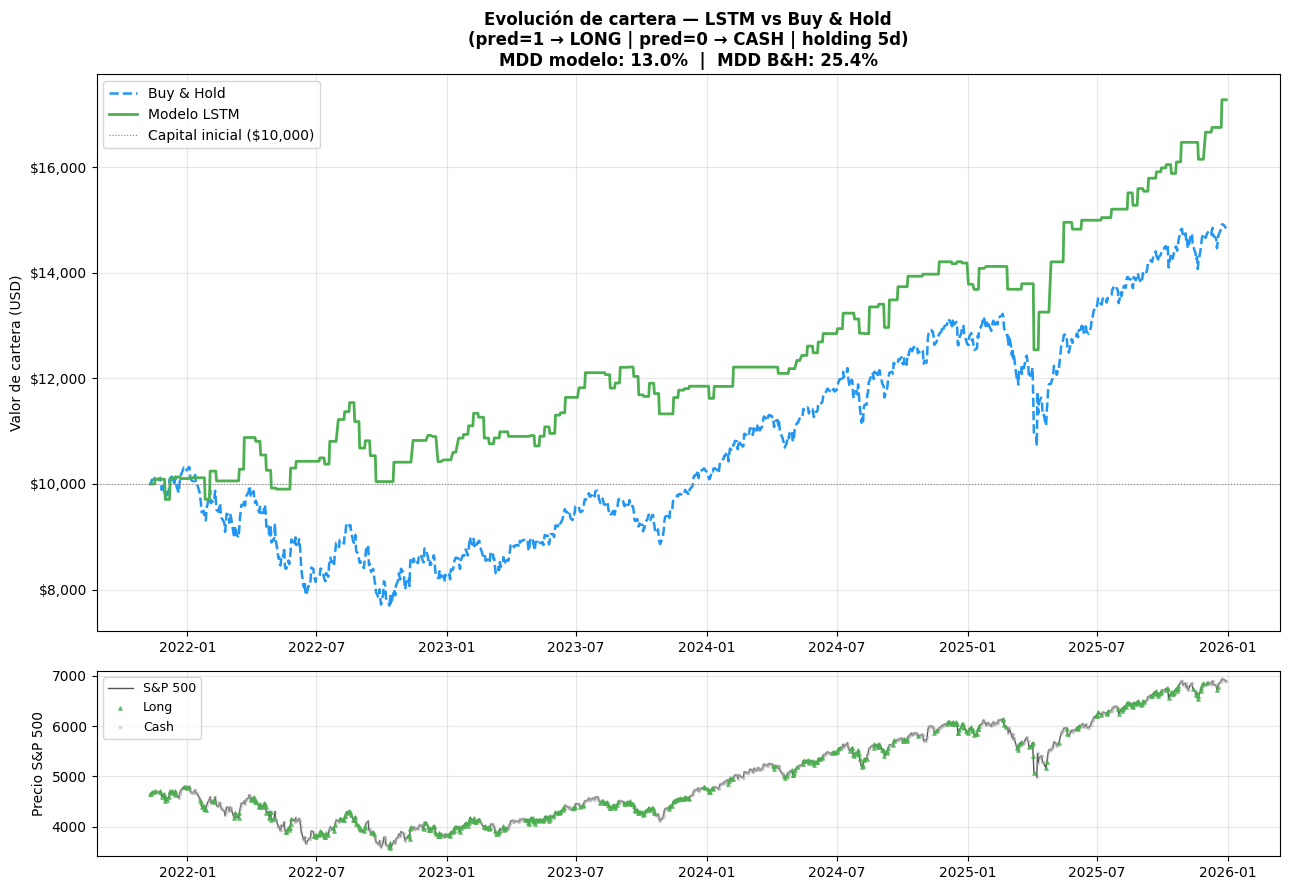


Resultados registrados en resultados_comparativa['LSTM']


In [27]:
close_test_lstm = test['CLOSE'].iloc[L-1:]
sim_lstm = simular_cartera('LSTM', y_pred_lstm, close_test_lstm)
resultados_comparativa['LSTM'] = sim_lstm
print("\nResultados registrados en resultados_comparativa['LSTM']")

### Comparativa de los tres modelos

Modelo                 Ret.mod   Ret.B&H     MDD  % invert        Capital  N ops    Win%  R.med/op
--------------------------------------------------------------------------------------------------
Regresión Logística      98.5%     50.0%   12.1%     70.2%  $      19,855    147   62.6%    +0.50%
Random Forest            63.0%     50.0%   17.5%     79.3%  $      16,304    166   61.5%    +0.32%
LSTM                     72.8%     48.4%   13.0%     61.7%  $      17,277    128   63.3%    +0.46%
Buy & Hold               50.0%     50.0%   25.4%    100.0%  $      15,004      1       -         -


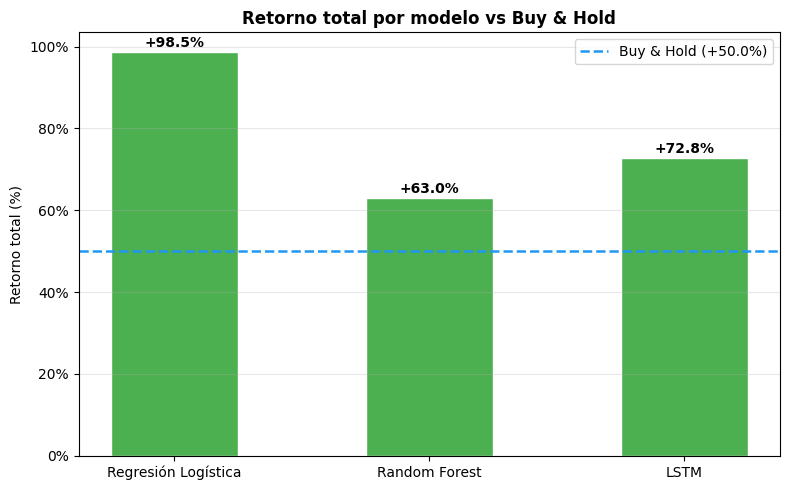

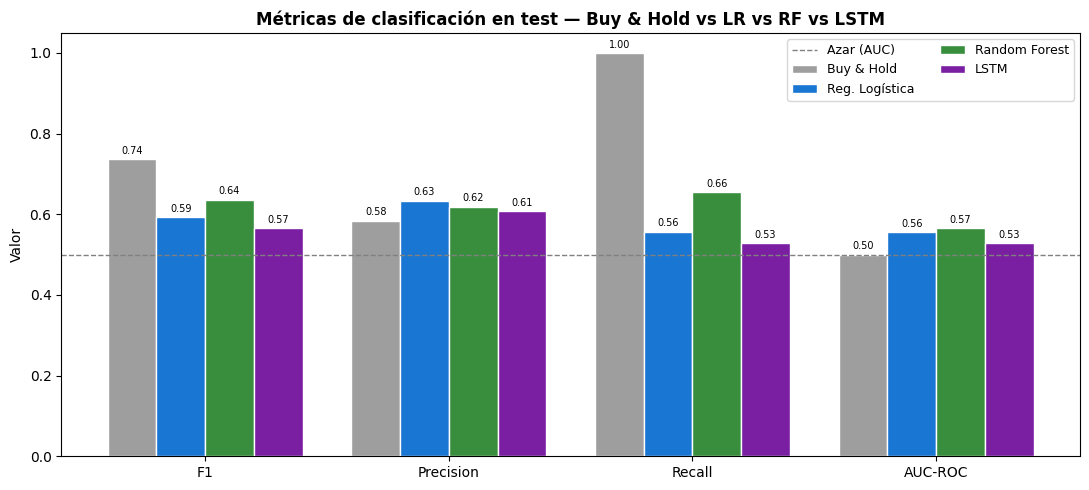

\nBuy & Hold como clasificador (predice siempre Clase 1):
  F1=0.7378  Precision=0.5845  Recall=1.0000  AUC-ROC=0.5000


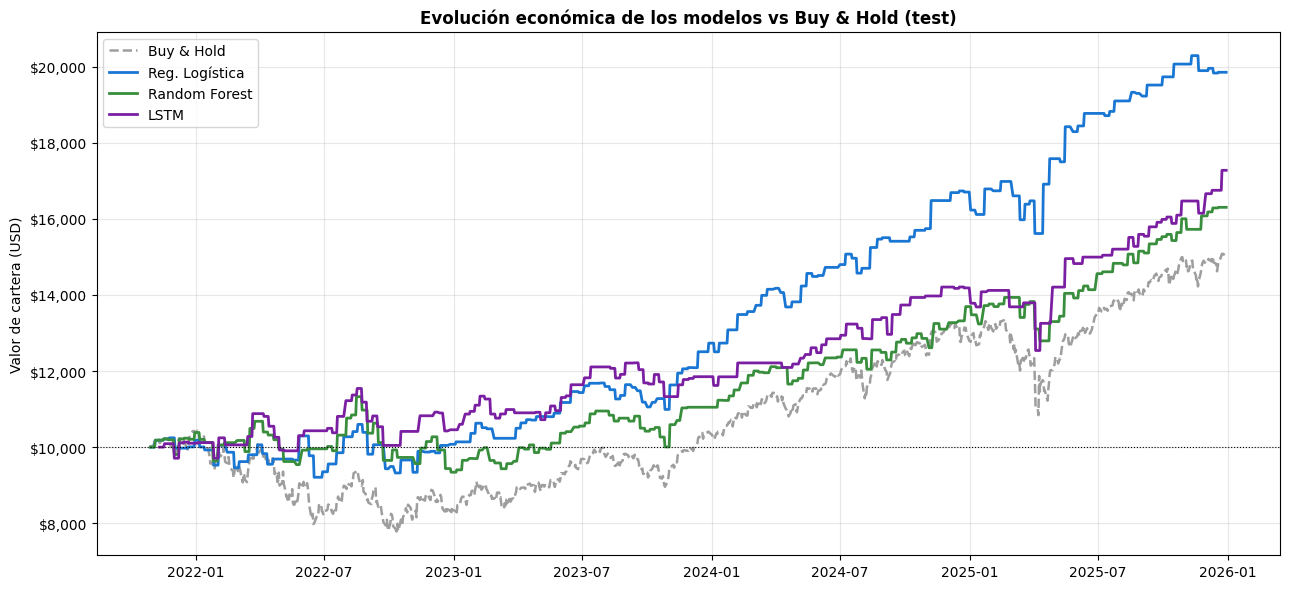

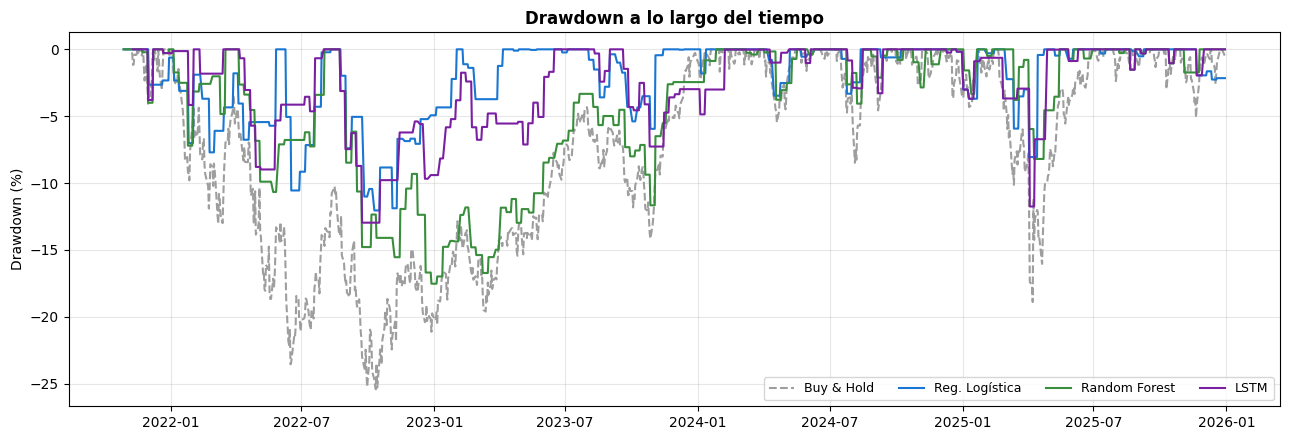

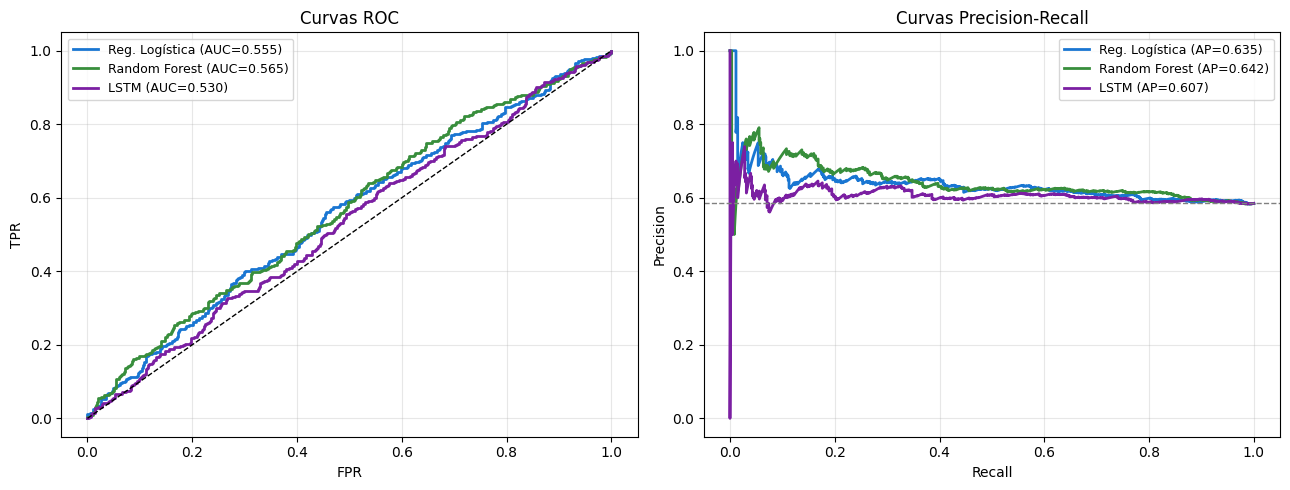

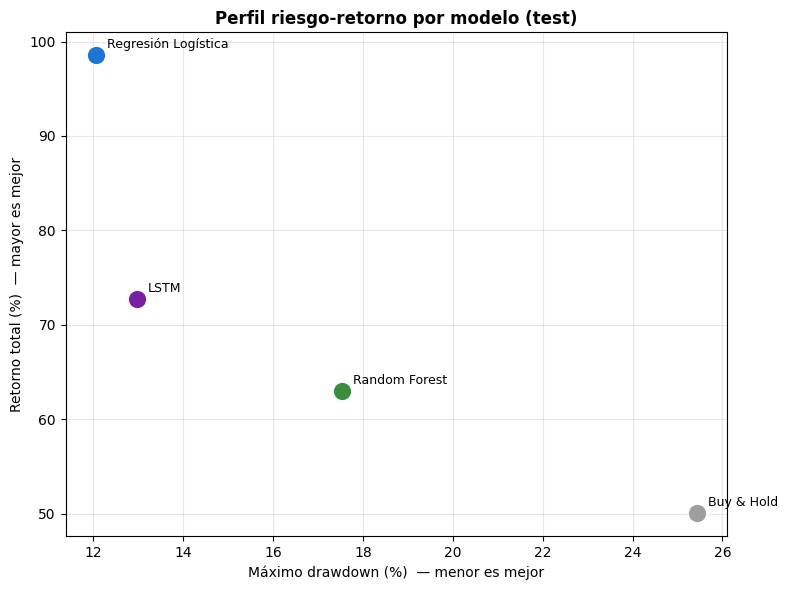

In [28]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mtick
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

nombres = list(resultados_comparativa.keys())
bh = resultados_comparativa[nombres[0]]
hdr = (f"{'Modelo':<20}{'Ret.mod':>10}{'Ret.B&H':>10}{'MDD':>8}"
       f"{'% invert':>10}{'Capital':>15}{'N ops':>7}{'Win%':>8}{'R.med/op':>10}")
print(hdr)
print("-" * len(hdr))
for m in nombres:
    r = resultados_comparativa[m]
    print(f"{m:<20}{r['retorno_modelo_%']:>9.1f}%{r['retorno_bh_%']:>9.1f}%{r['max_drawdown_%']:>7.1f}%"
          f"{r['pct_tiempo_mercado_%']:>9.1f}%  ${r['capital_final_modelo']:>12,.0f}{r['n_operaciones']:>7}"
          f"{r['win_rate_%']:>7.1f}%{r['avg_ret_op_%']:>+9.2f}%")
print(f"{'Buy & Hold':<20}{bh['retorno_bh_%']:>9.1f}%{bh['retorno_bh_%']:>9.1f}%{bh['max_drawdown_bh_%']:>7.1f}%"
      f"{100.0:>9.1f}%  ${bh['capital_final_bh']:>12,.0f}{'1':>7}{'-':>8}{'-':>10}")

ret_bh = bh['retorno_bh_%']
rets = [resultados_comparativa[m]['retorno_modelo_%'] for m in nombres]
fig, ax = plt.subplots(figsize=(8, 5))
colb = ['#4CAF50' if r >= ret_bh else '#f44336' for r in rets]
barras = ax.bar(nombres, rets, color=colb, edgecolor='white', width=0.5)
ax.axhline(ret_bh, color='#2196F3', ls='--', lw=1.8, label=f'Buy & Hold ({ret_bh:+.1f}%)')
for b, r in zip(barras, rets):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{r:+.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Retorno total (%)')
ax.set_title('Retorno total por modelo vs Buy & Hold', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

y_pred_bh = np.ones_like(y_test)
y_prob_bh = np.full(len(y_test), 0.5)
modelos = {'Buy & Hold':     (y_test,      y_pred_bh,   y_prob_bh),
           'Reg. Logística': (y_test,      y_pred_lr,   y_prob_lr),
           'Random Forest':  (y_test,      y_pred_rf,   y_prob_rf),
           'LSTM':           (y_test_lstm, y_pred_lstm, y_prob_lstm)}
metricas = ['F1', 'Precision', 'Recall', 'AUC-ROC']
vals = {m: [f1_score(yt, yp, zero_division=0), precision_score(yt, yp, zero_division=0),
            recall_score(yt, yp, zero_division=0), roc_auc_score(yt, pp)]
        for m, (yt, yp, pp) in modelos.items()}
cols = {'Buy & Hold': '#9E9E9E', 'Reg. Logística': '#1976D2', 'Random Forest': '#388E3C', 'LSTM': '#7B1FA2'}
x = np.arange(len(metricas))
nmod = len(modelos)
w = 0.8 / nmod
fig, ax = plt.subplots(figsize=(11, 5))
for i, (m, v) in enumerate(vals.items()):
    off = (i - (nmod-1)/2) * w
    bars = ax.bar(x + off, v, w, label=m, color=cols[m], edgecolor='white')
    for b, val in zip(bars, v):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.008, f'{val:.2f}', ha='center', va='bottom', fontsize=7)
ax.axhline(0.5, color='grey', ls='--', lw=1, label='Azar (AUC)')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.set_title('Métricas de clasificación en test — Buy & Hold vs LR vs RF vs LSTM', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

print("\\nBuy & Hold como clasificador (predice siempre Clase 1):")
print(f"  F1={vals['Buy & Hold'][0]:.4f}  Precision={vals['Buy & Hold'][1]:.4f}  "
      f"Recall={vals['Buy & Hold'][2]:.4f}  AUC-ROC={vals['Buy & Hold'][3]:.4f}")

from sklearn.metrics import roc_curve, precision_recall_curve

def _serie_cap(sig, precios, cap=CAPITAL_INICIAL, gap=GAP_DIAS):
    precios = np.asarray(precios, dtype=float)
    n = len(precios)
    s = np.asarray(sig).astype(int)
    modc = np.empty(n)
    c = cap
    inpos = False
    pe = 0.0
    ds = -1
    for i in range(n):
        if inpos and i == ds:
            c *= precios[i]/pe
            inpos = False
        modc[i] = c
        if not inpos and i + gap < n and s[i] == 1:
            inpos = True
            pe = precios[i]
            ds = i + gap
    if inpos:
        c *= precios[-1]/pe
        for j in range(ds, n): modc[j] = c
    return modc, cap * precios / precios[0]
def _dd(serie):
    peak = np.maximum.accumulate(serie)
    return (serie - peak) / peak * 100

precio_full = test['CLOSE'].values
fechas_full = test.index
lr_cap, bh_cap = _serie_cap(y_pred_lr, precio_full)
rf_cap, _      = _serie_cap(y_pred_rf, precio_full)
ls_cap, _      = _serie_cap(y_pred_lstm, test['CLOSE'].iloc[L-1:].values)
fechas_ls      = test.index[L-1:]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(fechas_full, bh_cap, color='#9E9E9E', ls='--', lw=1.8, label='Buy & Hold')
ax.plot(fechas_full, lr_cap, color='#1976D2', lw=2, label='Reg. Logística')
ax.plot(fechas_full, rf_cap, color='#388E3C', lw=2, label='Random Forest')
ax.plot(fechas_ls,   ls_cap, color='#7B1FA2', lw=2, label='LSTM')
ax.axhline(CAPITAL_INICIAL, color='black', ls=':', lw=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylabel('Valor de cartera (USD)')
ax.set_title('Evolución económica de los modelos vs Buy & Hold (test)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(fechas_full, _dd(bh_cap), color='#9E9E9E', ls='--', lw=1.5, label='Buy & Hold')
ax.plot(fechas_full, _dd(lr_cap), color='#1976D2', lw=1.5, label='Reg. Logística')
ax.plot(fechas_full, _dd(rf_cap), color='#388E3C', lw=1.5, label='Random Forest')
ax.plot(fechas_ls,   _dd(ls_cap), color='#7B1FA2', lw=1.5, label='LSTM')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown a lo largo del tiempo', fontsize=12, fontweight='bold')
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nom, yt, pp, col in [('Reg. Logística', y_test, y_prob_lr, '#1976D2'),
                          ('Random Forest', y_test, y_prob_rf, '#388E3C'),
                          ('LSTM', y_test_lstm, y_prob_lstm, '#7B1FA2')]:
    fpr, tpr, _ = roc_curve(yt, pp)
    axes[0].plot(fpr, tpr, color=col, lw=2, label=f'{nom} (AUC={roc_auc_score(yt,pp):.3f})')
    pr, rc, _ = precision_recall_curve(yt, pp)
    axes[1].plot(rc, pr, color=col, lw=2, label=f'{nom} (AP={average_precision_score(yt,pp):.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[1].axhline(y_test.mean(),color='grey',ls='--',lw=1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for m, col in [('Regresión Logística','#1976D2'),('Random Forest','#388E3C'),('LSTM','#7B1FA2')]:
    r = resultados_comparativa[m]
    ax.scatter(r['max_drawdown_%'], r['retorno_modelo_%'], s=180, color=col, edgecolor='white', zorder=5)
    ax.annotate(m, (r['max_drawdown_%'], r['retorno_modelo_%']), textcoords='offset points', xytext=(8,5), fontsize=9)
_bh = resultados_comparativa['Regresión Logística']
ax.scatter(_bh['max_drawdown_bh_%'], _bh['retorno_bh_%'], s=180, color='#9E9E9E', edgecolor='white', zorder=5)
ax.annotate('Buy & Hold', (_bh['max_drawdown_bh_%'], _bh['retorno_bh_%']), textcoords='offset points', xytext=(8,5), fontsize=9)
ax.set_xlabel('Máximo drawdown (%)  — menor es mejor')
ax.set_ylabel('Retorno total (%)  — mayor es mejor')
ax.set_title('Perfil riesgo-retorno por modelo (test)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Robustez: evaluación en 2022-2023

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, matplotlib.pyplot as plt, matplotlib.ticker as mtick, warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score

def _serie_cap_r(sig, precios, cap=CAPITAL_INICIAL, gap=GAP_DIAS):
    precios=np.asarray(precios,dtype=float)
    n=len(precios)
    s=np.asarray(sig).astype(int)
    modc=np.empty(n)
    c=cap
    inpos=False
    pe=0.0
    ds=-1
    ops=[]
    for i in range(n):
        if inpos and i==ds:
            c*=precios[i]/pe
            ops.append(precios[i]/pe-1)
            inpos=False
        modc[i]=c
        if not inpos and i+gap<n and s[i]==1:
            inpos=True
            pe=precios[i]
            ds=i+gap
    if inpos:
        c*=precios[-1]/pe
        for j in range(ds,n): modc[j]=c
    peak=np.maximum.accumulate(modc)
    mdd=((peak-modc)/peak).max()*100
    return modc, cap*precios/precios[0], len(ops), len(ops)*gap/n*100, mdd

def evaluar_periodo(test_ini, test_fin):
    tr = dataset[dataset.index <  pd.Timestamp(test_ini)].iloc[:-GAP_DIAS]
    te = dataset[(dataset.index >= pd.Timestamp(test_ini)) & (dataset.index <= pd.Timestamp(test_fin))]
    sc = StandardScaler().fit(tr[EFECTIVAS])
    Xtr, Xte = sc.transform(tr[EFECTIVAS]), sc.transform(te[EFECTIVAS])
    ytr = tr['Target'].values.astype('float32')
    yte = te['Target'].values.astype('float32')
    close = te['CLOSE'].values.astype(float)
    tscv = TimeSeriesSplit(5)
    res = {}
    bh_cap = CAPITAL_INICIAL * close / close[0]
    res['B&H'] = {'ret': (close[-1]/close[0]-1)*100}
    best=-1
    Co=1
    for C in np.logspace(-4,4,25):
        s=cross_val_score(LogisticRegression(C=C,class_weight='balanced',max_iter=1500,random_state=42),Xtr,ytr,cv=tscv,scoring='f1',n_jobs=-1).mean()
        if s>best:
            best=s
            Co=C
    lr=LogisticRegression(C=Co,class_weight='balanced',max_iter=4000,random_state=42).fit(Xtr,ytr)
    pl,ql=lr.predict(Xte),lr.predict_proba(Xte)[:,1]
    cap,_,_,exp,mdd=_serie_cap_r(pl,close)
    res['Reg. Logística']={'f1':f1_score(yte,pl,zero_division=0),'auc':roc_auc_score(yte,ql),'ret':(cap[-1]/CAPITAL_INICIAL-1)*100,'mdd':mdd,'exp':exp,'cap':cap}
    pdg=dict(n_estimators=[200,300,500],max_depth=[4,6,8,10,15],min_samples_leaf=[2,4,6,8],min_samples_split=[4,6,8],max_features=['sqrt','log2',0.3,0.5],bootstrap=[True],criterion=['gini','entropy'])
    rf=RandomizedSearchCV(RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1),pdg,n_iter=30,scoring='f1',cv=tscv,random_state=42,n_jobs=-1).fit(Xtr,ytr).best_estimator_
    pr,qr=rf.predict(Xte),rf.predict_proba(Xte)[:,1]
    cap,_,_,exp,mdd=_serie_cap_r(pr,close)
    res['Random Forest']={'f1':f1_score(yte,pr,zero_division=0),'auc':roc_auc_score(yte,qr),'ret':(cap[-1]/CAPITAL_INICIAL-1)*100,'mdd':mdd,'exp':exp,'cap':cap}
    Lr=int(best_lstm['L'])
    Hr=int(best_lstm['hidden'])
    NLr=int(best_lstm['layers'])
    DOr=float(best_lstm['dropout'])
    LRr=float(best_lstm['lr'])
    BSr=int(best_lstm['bs'])
    WDr=float(best_lstm['wd'])
    EPr=int(best_lstm['best_ep'])
    Xf,yf=make_seq(Xtr,ytr,Lr)
    Xtes,ytes=make_seq(Xte,yte,Lr)
    closeL=close[Lr-1:]
    probs=[]
    for sd in [0,1,2]:
        torch.manual_seed(sd)
        m=LSTMClassifier(Xf.shape[2],Hr,NLr,DOr)
        pos=yf.sum()
        neg=len(yf)-pos
        crit=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/max(pos,1)],dtype=torch.float32))
        opt=torch.optim.Adam(m.parameters(),lr=LRr,weight_decay=WDr)
        Xf_t,yf_t=torch.tensor(Xf),torch.tensor(yf)
        for ep in range(EPr):
            m.train()
            perm=torch.randperm(len(Xf))
            for j in range(0,len(Xf),BSr):
                idx=perm[j:j+BSr]
                opt.zero_grad()
                loss=crit(m(Xf_t[idx]),yf_t[idx])
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(),1.0)
                opt.step()
        m.eval()
        with torch.no_grad(): probs.append(torch.sigmoid(m(torch.tensor(Xtes))).numpy())
    qL=np.mean(probs,axis=0)
    pL=(qL>=0.5).astype(int)
    cap,_,_,exp,mdd=_serie_cap_r(pL,closeL)
    res['LSTM']={'f1':f1_score(ytes,pL,zero_division=0),'auc':roc_auc_score(ytes,qL),'ret':(cap[-1]/CAPITAL_INICIAL-1)*100,'mdd':mdd,'exp':exp,'cap':cap,'fechas':te.index[Lr-1:]}
    res['_meta']={'fechas':te.index,'bh_cap':bh_cap,'bh_ret':res['B&H']['ret'],
                  'periodo':f"{te.index.min().date()} a {te.index.max().date()}",'clase1':yte.mean()*100}
    return res

rob = evaluar_periodo('2022-01-01','2023-12-31')
m = rob['_meta']
print(f"Periodo no alcista: {m['periodo']}  |  Buy & Hold {m['bh_ret']:+.1f}%  |  Clase 1 = {m['clase1']:.0f}%\n")
hdr=f"{'Modelo':<18}{'F1':>8}{'AUC':>8}{'Retorno':>10}{'MDD':>8}{'% invert':>10}"
print(hdr)
print('-'*len(hdr))
for mod in ['Reg. Logística','Random Forest','LSTM']:
    r=rob[mod]
    print(f"{mod:<18}{r['f1']:>8.3f}{r['auc']:>8.3f}{r['ret']:>9.1f}%{r['mdd']:>7.1f}%{r['exp']:>9.1f}%")
print(f"{'Buy & Hold':<18}{'-':>8}{'0.500':>8}{m['bh_ret']:>9.1f}%{'-':>8}{'100.0':>9}%")

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(m['fechas'], m['bh_cap'], color='#9E9E9E', ls='--', lw=1.8, label='Buy & Hold')
ax.plot(m['fechas'], rob['Reg. Logística']['cap'], color='#1976D2', lw=2, label='Reg. Logística')
ax.plot(m['fechas'], rob['Random Forest']['cap'], color='#388E3C', lw=2, label='Random Forest')
ax.plot(rob['LSTM']['fechas'], rob['LSTM']['cap'], color='#7B1FA2', lw=2, label='LSTM')
ax.axhline(CAPITAL_INICIAL, color='black', ls=':', lw=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_ylabel('Valor de cartera (USD)')
ax.set_title('Evolución económica en periodo no alcista (2022-2023)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

### Preparación del panel de constituyentes

In [ ]:
import yfinance as yf, ta, numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')

TICKERS_PANEL = ("AAPL MSFT JNJ JPM XOM PG KO PEP WMT HD CVX PFE MRK CSCO ORCL INTC IBM T VZ DIS "
                 "MCD NKE MMM CAT BA HON UNH ABT MDT AMGN GILD COST LOW TGT SBUX QCOM TXN WFC BAC C GS MS AXP USB").split()
CUT_PANEL = '2021-10-28'
THR_MOVE = 0.01
GAP_P = 5
L_P = 20
EF_P = ['SMA_10_NORM','rMACD','RSI_7','ROC_5','ROC_20','VIX_Z','TNX_CHG20','MFI_14','VOL_REL','ATR_PCT','BB_WIDTH','ADX_14']

print(f"Descargando {len(TICKERS_PANEL)} valores + VIX + TNX (puede tardar)...")
raw_panel = yf.download(TICKERS_PANEL + ['^VIX','^TNX'], start='2005-01-01', end='2025-12-31',
                        auto_adjust=False, progress=False, group_by='ticker')
_vix = raw_panel['^VIX']['Close']
_tnx = raw_panel['^TNX']['Close']
_vixz = (_vix - _vix.rolling(50).mean()) / _vix.rolling(50).std()
_tnxc = _tnx.diff(20)

def _feats_panel(t):
    d = raw_panel[t]
    c = d['Close'].squeeze()
    h = d['High'].squeeze()
    l = d['Low'].squeeze()
    v = d['Volume'].squeeze()
    if c.dropna().shape[0] < 2000: return None
    o = pd.DataFrame(index=d.index)
    o['SMA_10_NORM'] = c / ta.trend.SMAIndicator(c,10).sma_indicator()
    _m = ta.trend.MACD(c,12,26,9)
    _den = 0.5*(_m.macd().abs()+_m.macd_signal().abs())
    o['rMACD'] = (_m.macd()-_m.macd_signal())/_den.replace(0,np.nan)
    o['RSI_7'] = ta.momentum.RSIIndicator(c,7).rsi()/100
    o['ROC_5'] = c.pct_change(5)
    o['ROC_20'] = c.pct_change(20)
    o['VIX_Z'] = _vixz.reindex(d.index)
    o['TNX_CHG20'] = _tnxc.reindex(d.index)
    o['MFI_14'] = ta.volume.MFIIndicator(h,l,c,v,14).money_flow_index()/100
    o['VOL_REL'] = v / v.rolling(20).mean()
    o['ATR_PCT'] = ta.volatility.AverageTrueRange(h,l,c,14).average_true_range()/c
    _bb = ta.volatility.BollingerBands(c,20,2)
    o['BB_WIDTH'] = (_bb.bollinger_hband()-_bb.bollinger_lband())/_bb.bollinger_mavg()
    o['ADX_14'] = ta.trend.ADXIndicator(h,l,c,14).adx()/100
    _fut = c.shift(-GAP_P)/c - 1
    o['ret'] = _fut
    o['Target'] = np.where(_fut > THR_MOVE, 1, np.where(_fut < -THR_MOVE, 0, np.nan))
    o['ticker'] = t
    return o

frames_panel = [f for f in (_feats_panel(t) for t in TICKERS_PANEL) if f is not None]
print(f"Valores válidos en el panel: {len(frames_panel)}")
_n_tot = sum(f[EF_P].notna().all(axis=1).sum() for f in frames_panel)
print(f"Filas con features completas: ~{_n_tot:,}")

Descargando 44 valores + VIX + TNX (puede tardar)...
Valores válidos en el panel: 44
Filas con features completas: ~229,812


### Augmentation: conjunto de entrenamiento aumentado

In [ ]:
# conjunto de entrenamiento aumentado con el panel de acciones
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
CUT_IDX = test.index[0]
Xtr_idx = train[EFECTIVAS].values
ytr_idx = y_train.astype(int)
Xte_idx = test[EFECTIVAS].values
yte_idx = y_test.astype(int)
_AX = [Xtr_idx]
_AY = [ytr_idx]
_nacc = 0
for f in frames_panel:
    m = f[EF_P].notna().all(axis=1) & f['ret'].notna() & (f.index < CUT_IDX)
    d = f[m]
    if len(d) == 0: continue
    _AX.append(d[EF_P].values)
    _AY.append((d['ret'].values >= 0).astype(int))
    _nacc += len(d)
Xtr_aug = np.vstack(_AX)
ytr_aug = np.concatenate(_AY)
scaler_aug = StandardScaler().fit(Xtr_aug)
Xtr_aug_s = scaler_aug.transform(Xtr_aug)
Xte_idx_s = scaler_aug.transform(Xte_idx)
print(f"Train aumentado: {Xtr_aug.shape}  (índice {len(ytr_idx)} + acciones {_nacc})")
print(f"Test (solo índice): {Xte_idx.shape}  | Clase 1: train {ytr_aug.mean()*100:.0f}% test {yte_idx.mean()*100:.0f}%")

Train aumentado: (187925, 12)  (índice 4181 + acciones 183744)
Test (solo índice): (1047, 12)  | Clase 1: train 54% test 58%


### Augmentation: LR y RF

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score
tscv_a = TimeSeriesSplit(5)
_b = -1
C_a = 1
for C in np.logspace(-4, 4, 18):
    s = cross_val_score(LogisticRegression(C=C, class_weight='balanced', max_iter=1000, random_state=42),
                        Xtr_aug_s, ytr_aug, cv=tscv_a, scoring='f1', n_jobs=-1).mean()
    if s > _b:
        _b = s
        C_a = C
lr_aug = LogisticRegression(C=C_a, class_weight='balanced', max_iter=3000, random_state=42).fit(Xtr_aug_s, ytr_aug)
yp_lr_a = lr_aug.predict(Xte_idx_s)
qp_lr_a = lr_aug.predict_proba(Xte_idx_s)[:, 1]
_pdg = dict(n_estimators=[300, 500], max_depth=[6, 10, 15], min_samples_leaf=[5, 10, 20],
            min_samples_split=[10, 20], max_features=['sqrt', 0.3], bootstrap=[True], criterion=['gini'])
rf_aug = RandomizedSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
                            _pdg, n_iter=12, scoring='f1', cv=tscv_a, random_state=42, n_jobs=-1).fit(Xtr_aug_s, ytr_aug).best_estimator_
yp_rf_a = rf_aug.predict(Xte_idx_s)
qp_rf_a = rf_aug.predict_proba(Xte_idx_s)[:, 1]
print(f"LR  aug (índice): F1={f1_score(yte_idx, yp_lr_a):.4f}  AUC={roc_auc_score(yte_idx, qp_lr_a):.4f}  (C={C_a:.4f})")
print(f"RF  aug (índice): F1={f1_score(yte_idx, yp_rf_a):.4f}  AUC={roc_auc_score(yte_idx, qp_rf_a):.4f}")

LR  aug (índice): F1=0.5732  AUC=0.5707  (C=0.0009)
RF  aug (índice): F1=0.6409  AUC=0.5724


### Augmentation: LSTM

In [34]:
import torch, torch.nn as nn, time
from sklearn.metrics import f1_score, roc_auc_score
torch.manual_seed(42)
DEV_A = 'mps' if torch.backends.mps.is_available() else 'cpu'

# --- config TUNEADA (coincide con LSTM indice y docx Tabla 4) ---
LA  = int(best_lstm['L'])
HA  = int(best_lstm['hidden'])
NLA = int(best_lstm['layers'])
DOA = float(best_lstm['dropout'])
LRA = float(best_lstm['lr'])      # 5e-4
WDA = float(best_lstm['wd'])
BSA = int(best_lstm['bs'])        # 64
EPA = int(best_lstm['best_ep'])   # 156
N_FEAT_A = len(EFECTIVAS)
SEEDS_A = [0]               # 1 seed (panel sin señal: varianza entre seeds despreciable, AUC~0.5)

def _seqA(X, y, L):
    return ([X[i-L+1:i+1] for i in range(L-1, len(X))],
            [y[i]          for i in range(L-1, len(X))])

# --- construccion de secuencias aumentadas ---
print(f"[1/4] Construyendo secuencias (LA={LA}, {len(frames_panel)} frames)...", flush=True)
_t0 = time.time()
SX, SY = [], []
_xi = scaler_aug.transform(train[EFECTIVAS].values).astype('float32')
_a, _b = _seqA(_xi, y_train.astype('float32'), LA)
SX += _a
SY += _b
for k, f in enumerate(frames_panel):
    m = f[EF_P].notna().all(axis=1) & f['ret'].notna() & (f.index < CUT_IDX)
    d = f[m]
    if len(d) < LA: continue
    xs = scaler_aug.transform(d[EF_P].values).astype('float32')
    rr = d['ret'].values
    ys = (rr >= 0).astype('float32')
    valid = ~np.isnan(rr)
    for i in range(LA-1, len(xs)):
        if valid[i]:
            SX.append(xs[i-LA+1:i+1])
            SY.append(ys[i])
Xtr_seqA = np.asarray(SX, 'float32')
ytr_seqA = np.asarray(SY, 'float32')
_xte = scaler_aug.transform(test[EFECTIVAS].values).astype('float32')
_a, _b = _seqA(_xte, y_test.astype('float32'), LA)
Xte_seqA = np.asarray(_a, 'float32')
yte_seqA = np.asarray(_b, 'float32')
print(f"[2/4] Listo en {time.time()-_t0:.1f}s -> train {Xtr_seqA.shape}  test {Xte_seqA.shape}  device={DEV_A}", flush=True)

Xt = torch.tensor(Xtr_seqA).to(DEV_A)
yt = torch.tensor(ytr_seqA).to(DEV_A)
pos = ytr_seqA.sum()
neg = len(ytr_seqA) - pos
pw  = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(DEV_A)
N_STEPS = (len(Xt) + BSA - 1) // BSA
print(f"[3/4] Xt en {DEV_A}: {tuple(Xt.shape)}  |  {N_STEPS} batches/ep (BS={BSA}, lr={LRA:.1e}) x {EPA} ep x {len(SEEDS_A)} seeds", flush=True)

INF_BS = 1024
def _infer(model, Xnp):
    model.eval()
    Xq = torch.tensor(Xnp)
    out = []
    with torch.no_grad():
        for j in range(0, len(Xq), INF_BS):
            out.append(torch.sigmoid(model(Xq[j:j+INF_BS].to(DEV_A))).cpu())
    return torch.cat(out).numpy()

print(f"[4/4] Entrenando ensemble ({len(SEEDS_A)} seeds)...", flush=True)
probs = []
for si, sd in enumerate(SEEDS_A):
    torch.manual_seed(sd)
    m  = LSTMClassifier(N_FEAT_A, HA, NLA, DOA).to(DEV_A)
    cr = nn.BCEWithLogitsLoss(pos_weight=pw)
    op = torch.optim.Adam(m.parameters(), lr=LRA, weight_decay=WDA)
    _ts = time.time()
    for ep in range(EPA):
        m.train()
        pm = torch.randperm(len(Xt), device=DEV_A)
        tot = torch.zeros((), device=DEV_A)   # acumula en GPU; sin sync por batch
        for j in range(0, len(Xt), BSA):
            idx = pm[j:j+BSA]
            op.zero_grad()
            loss = cr(m(Xt[idx]), yt[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            op.step()
            tot += loss.detach() * len(idx)
        if (ep+1) % 20 == 0 or ep == EPA-1:
            print(f"  seed {sd} ({si+1}/{len(SEEDS_A)})  ep={ep+1:3d}/{EPA}  loss_med={(tot/len(Xt)).item():.4f}  ({time.time()-_ts:.0f}s)", flush=True)
    probs.append(_infer(m, Xte_seqA))
    print(f"  seed {sd} completado en {time.time()-_ts:.0f}s", flush=True)

qp_ls_a = np.mean(probs, 0)
yp_ls_a = (qp_ls_a >= 0.5).astype(int)
print(f"\nLSTM aug (indice): F1={f1_score(yte_seqA, yp_ls_a):.4f}  AUC={roc_auc_score(yte_seqA, qp_ls_a):.4f}")


[1/4] Construyendo secuencias (LA=10, 44 frames)...
[2/4] Listo en 0.3s -> train (187520, 10, 12)  test (1038, 10, 12)  device=mps
[3/4] Xt en mps: (187520, 10, 12)  |  2930 batches/ep (BS=64, lr=5.0e-04) x 156 ep x 1 seeds
[4/4] Entrenando ensemble (1 seeds)...
  seed 0 (1/1)  ep= 20/156  loss_med=0.6297  (152s)


KeyboardInterrupt: 

### Augmentation: comparativa

In [ ]:
close_idx = test['CLOSE']
sim_lr_a = simular_cartera('LR (aug)',   yp_lr_a, close_idx,             plot=False, verbose=False)
sim_rf_a = simular_cartera('RF (aug)',   yp_rf_a, close_idx,             plot=False, verbose=False)
sim_ls_a = simular_cartera('LSTM (aug)', yp_ls_a, close_idx.iloc[LA-1:], plot=False, verbose=False)
print(f"{'Modelo (aug)':<14}{'F1':>8}{'AUC':>8}{'Retorno':>10}{'MDD':>8}{'B&H':>9}")
print('-'*57)
for nom, yp, qp, yt, sim in [('LR', yp_lr_a, qp_lr_a, yte_idx, sim_lr_a),
                             ('RF', yp_rf_a, qp_rf_a, yte_idx, sim_rf_a),
                             ('LSTM', yp_ls_a, qp_ls_a, yte_seqA, sim_ls_a)]:
    print(f"{nom:<14}{f1_score(yt,yp):>8.3f}{roc_auc_score(yt,qp):>8.3f}{sim['retorno_modelo_%']:>9.1f}%{sim['max_drawdown_%']:>7.1f}%{sim['retorno_bh_%']:>8.1f}%")
print("\nAumentación aplicada por igual a los tres modelos. Comparar con la versión índice-solo (Capítulo de resultados).")

In [ ]:
import torch, torch.nn as nn
from sklearn.metrics import roc_auc_score
torch.manual_seed(0)
Xo = torch.tensor(Xtr_seqA[:2000]).to(DEV_A)
yo = torch.tensor(ytr_seqA[:2000]).to(DEV_A)
mo = LSTMClassifier(N_FEAT_A, HA, NLA, DOA).to(DEV_A)
op = torch.optim.Adam(mo.parameters(), lr=1e-3)
cr = nn.BCEWithLogitsLoss()
for ep in range(300):
    mo.train()
    op.zero_grad()
    loss = cr(mo(Xo), yo)
    loss.backward()
    op.step()
    if (ep+1)%50==0:
        mo.eval()
        with torch.no_grad(): p=torch.sigmoid(mo(Xo)).cpu().numpy()
        print(f"ep{ep+1} loss={loss.item():.4f} AUC_overfit={roc_auc_score(ytr_seqA[:2000],p):.4f}")

ep50 loss=0.6731 AUC_overfit=0.5895
ep100 loss=0.6314 AUC_overfit=0.6921
ep150 loss=0.5497 AUC_overfit=0.7945
ep200 loss=0.4522 AUC_overfit=0.8731
ep250 loss=0.3582 AUC_overfit=0.9253
ep300 loss=0.2833 AUC_overfit=0.9550


In [ ]:
import torch, torch.nn as nn
from sklearn.metrics import roc_auc_score
torch.manual_seed(0)
Xo = torch.tensor(Xtr_seqA[:2000]).to(DEV_A)
yo = torch.tensor(ytr_seqA[:2000]).to(DEV_A)
mo = LSTMClassifier(N_FEAT_A, HA, NLA, DOA).to(DEV_A)
op = torch.optim.Adam(mo.parameters(), lr=1e-3)
cr = nn.BCEWithLogitsLoss()
for ep in range(300):
    mo.train()
    op.zero_grad()
    loss = cr(mo(Xo), yo)
    loss.backward()
    op.step()
    if (ep+1)%50==0:
        mo.eval()
        with torch.no_grad(): p=torch.sigmoid(mo(Xo)).cpu().numpy()
        print(f"ep{ep+1} loss={loss.item():.4f} AUC_overfit={roc_auc_score(ytr_seqA[:2000],p):.4f}")

ep50 loss=0.6731 AUC_overfit=0.5895
ep100 loss=0.6314 AUC_overfit=0.6921
ep150 loss=0.5497 AUC_overfit=0.7945
ep200 loss=0.4522 AUC_overfit=0.8731
ep250 loss=0.3582 AUC_overfit=0.9253
ep300 loss=0.2833 AUC_overfit=0.9550


In [ ]:
print("best_ep =", int(best_lstm['best_ep']))
print("config :", {k:best_lstm[k] for k in ['L','hidden','layers','dropout','lr','bs','wd']})
print("val_auc=", round(float(best_lstm['val_auc']),4), " val_f1=", round(float(best_lstm['val_f1']),4))

best_ep = 156
config : {'L': 10.0, 'hidden': 16.0, 'layers': 2.0, 'dropout': 0.2, 'lr': 0.0005, 'bs': 64.0, 'wd': 0.001}
val_auc= 0.5939  val_f1= 0.6413


In [ ]:
import numpy as np
_bc = {k:(int(best_lstm[k]) if k in ['L','hidden','layers','bs'] else float(best_lstm[k])) for k in ['L','hidden','layers','dropout','lr','bs','wd']}
_Xs,_ys = make_seq(Xtf, ytf, _bc['L'])
_Xv,_yv = make_seq(Xvl, yvl, _bc['L'])
# re-corre 1 seed capturando hist completo (max_ep alto, sin parar)
_,_f1,_auc,_mep,_hist = entrenar_lstm(_Xs,_ys,_Xv,_yv,_bc['hidden'],_bc['layers'],_bc['dropout'],
                                      _bc['lr'],_bc['bs'],_bc['wd'], seed=0, max_ep=200, paciencia=999, min_ep=200)
_H = np.array(_hist)  # cols: train_loss, f1_val, auc_val
_loss,_f1v,_aucv = _H[:,0],_H[:,1],_H[:,2]
print("epochs corridos:", len(_H))
print("AUC val  max =", round(_aucv.max(),4), "en ep", int(_aucv.argmax())+1)
# criterio actual (margen 1e-4)
_best=-1
_be=0
for e,a in enumerate(_aucv):
    if a> _best+1e-4:
        _best=a
        _be=e+1
print("best_ep criterio actual (margen 1e-4):", _be)
# criterio robusto 1: AUC suavizado (media movil 7), argmax
def _sm(x,w=7):
    k=np.ones(w)/w
    return np.convolve(x,k,mode='same')
_aucs=_sm(_aucv)
print("best_ep AUC suavizado (w7) argmax:", int(_aucs.argmax())+1, " AUC_suav=",round(_aucs.max(),4))
# criterio robusto 2: primer epoch dentro de 1 std del max
_std=_aucv.std()
_thr=_aucv.max()-_std
_first=int(np.argmax(_aucv>=_thr))+1
print(f"best_ep primer ep dentro de 1 std (std={_std:.4f}, thr={_thr:.4f}):", _first)
print("\nAUC val por tramos:")
for e in [10,20,30,40,50,60,80,100,150,200]:
    if e<=len(_aucv): print(f"  ep{e:3d}: loss={_loss[e-1]:.4f}  AUC={_aucv[e-1]:.4f}  F1={_f1v[e-1]:.4f}")

epochs corridos: 200
AUC val  max = 0.5921 en ep 133
best_ep criterio actual (margen 1e-4): 133
best_ep AUC suavizado (w7) argmax: 136  AUC_suav= 0.587
best_ep primer ep dentro de 1 std (std=0.0430, thr=0.5491): 69

AUC val por tramos:
  ep 10: loss=0.5745  AUC=0.4421  F1=0.5362
  ep 20: loss=0.5642  AUC=0.4700  F1=0.5480
  ep 30: loss=0.5546  AUC=0.4936  F1=0.4977
  ep 40: loss=0.5383  AUC=0.5089  F1=0.5110
  ep 50: loss=0.5257  AUC=0.5164  F1=0.5379
  ep 60: loss=0.5101  AUC=0.5335  F1=0.5407
  ep 80: loss=0.4770  AUC=0.5605  F1=0.5609
  ep100: loss=0.4582  AUC=0.5772  F1=0.6099
  ep150: loss=0.4291  AUC=0.5852  F1=0.6734
  ep200: loss=0.4090  AUC=0.5760  F1=0.6606
